# Tier 2 Deep Learning Models

This notebook extends the fraud detection modeling pipeline from traditional machine learning to deep learning.

The first Tier 2 model is a Multilayer Perceptron (MLP) implemented with PyTorch. The model reuses the processed and scaled datasets produced during the data preparation phase, preserving the same chronological train, validation, and test splits used for the Tier 1 baseline models.

Average Precision (AP) remains the primary evaluation metric because of the extreme class imbalance in the fraud detection problem. Precision, Recall, F1-score, ROC-AUC, and the confusion matrix will be used as complementary diagnostic metrics.

The validation set is used for model development, early stopping, and comparison. Test distribution information was inspected during full-dataset EDA and integrity checks, but test data is excluded from fitting, hyperparameter optimization, early stopping, threshold optimization, and model selection until notebook 04. Final test results are held-out results, not a strictly blind holdout.

The saved neural artifacts are separate reproducible training runs from the original interactive notebook sessions. Stochastic training and notebook execution order led to differences from some historical notebook validation AP values. The historical results remain reference experiment results; notebook 04 evaluates the saved artifacts. Their reproduced validation AP values are MLP 0.846886 (historical 0.857221), Autoencoder 0.271484 (historical 0.285407), LSTM 0.846636 (historical 0.848276), and GRU 0.847515 (historical 0.843658). The artifacts load successfully; these differences are retained rather than presented as exact reproduction.

## 1. Data Handoff and Environment

In [116]:
# Import standard library modules used for reproducibility and path management.
import random
from pathlib import Path

# Import numerical and tabular data libraries.
import numpy as np
import pandas as pd

# Import Matplotlib for model evaluation visualizations.
import matplotlib.pyplot as plt

# Import PyTorch and the modules required to build and train the MLP.
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Import evaluation metrics from scikit-learn.
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

### 1.0 Reproducible Configuration

In [117]:
# Define a fixed random seed to make the MLP experiment reproducible.
RANDOM_SEED = 42

# Set the Python random seed.
random.seed(RANDOM_SEED)

# Set the NumPy random seed.
np.random.seed(RANDOM_SEED)

# Set the PyTorch CPU random seed.
torch.manual_seed(RANDOM_SEED)

# Set the PyTorch CUDA random seed when a GPU is available.
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Configure deterministic CUDA behavior where supported.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Print the configured seed.
print(f"Random seed: {RANDOM_SEED}")

Random seed: 42


### 1.1 Project Paths

In [ ]:
# Discover the repository root from Jupyter's current directory. This supports
# launches from either the repository root or its notebooks/ directory.
PROJECT_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "notebooks").is_dir()
        and (candidate / "data").is_dir()
        and (candidate / "models").is_dir()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the Bank-Fraud-Detection project root.")

# Define the directories used by the project.
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

# Define the processed datasets produced by the data preparation notebook.
X_TRAIN_PATH = PROCESSED_DIR / "X_train_scaled.parquet"
X_VAL_PATH = PROCESSED_DIR / "X_val_scaled.parquet"
X_TEST_PATH = PROCESSED_DIR / "X_test_scaled.parquet"

Y_TRAIN_PATH = PROCESSED_DIR / "y_train.parquet"
Y_VAL_PATH = PROCESSED_DIR / "y_val.parquet"
Y_TEST_PATH = PROCESSED_DIR / "y_test.parquet"

# Print the resolved project paths to verify the notebook location and file structure.
print(f"Project root: {PROJECT_ROOT.resolve()}")
print(f"Processed data directory: {PROCESSED_DIR.resolve()}")
print(f"Models directory: {MODELS_DIR.resolve()}")

### 1.2 Processed Dataset Availability

In [119]:
# Store all processed dataset paths in a dictionary for a single availability check.
processed_files = {
    "X_train_scaled": X_TRAIN_PATH,
    "X_val_scaled": X_VAL_PATH,
    "X_test_scaled": X_TEST_PATH,
    "y_train": Y_TRAIN_PATH,
    "y_val": Y_VAL_PATH,
    "y_test": Y_TEST_PATH,
}

# Check whether every required processed dataset exists.
for file_name, file_path in processed_files.items():
    print(f"{file_name}: {file_path.exists()}")

X_train_scaled: True
X_val_scaled: True
X_test_scaled: True
y_train: True
y_val: True
y_test: True


### 1.3 Load Processed Datasets

In [120]:
# Load the scaled feature matrices produced by the data preparation phase.
X_train = pd.read_parquet(X_TRAIN_PATH)
X_val = pd.read_parquet(X_VAL_PATH)
X_test = pd.read_parquet(X_TEST_PATH)

# Load the target vectors for the training, validation, and test splits.
y_train = pd.read_parquet(Y_TRAIN_PATH).squeeze("columns")
y_val = pd.read_parquet(Y_VAL_PATH).squeeze("columns")
y_test = pd.read_parquet(Y_TEST_PATH).squeeze("columns")

# Print the shapes of all loaded datasets to verify the data handoff.
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (199364, 32)
X_val shape:   (42721, 32)
X_test shape:  (42722, 32)
y_train shape: (199364,)
y_val shape:   (42721,)
y_test shape:  (42722,)


### 1.4 Feature Contract

In [121]:
# Define the expected feature order established during data preparation.
EXPECTED_FEATURES = (
    [f"V{i}" for i in range(1, 29)]
    + ["Amount", "Amount_log", "Time", "Time_hour"]
)

# Verify that all splits contain exactly the expected features in the same order.
train_features_match = X_train.columns.tolist() == EXPECTED_FEATURES
val_features_match = X_val.columns.tolist() == EXPECTED_FEATURES
test_features_match = X_test.columns.tolist() == EXPECTED_FEATURES

# Print the feature contract validation results.
print(f"Number of expected features: {len(EXPECTED_FEATURES)}")
print(f"Train feature contract:      {train_features_match}")
print(f"Validation feature contract: {val_features_match}")
print(f"Test feature contract:       {test_features_match}")

# Display the feature names to make the input contract explicit.
print("\nFeature order:")
print(EXPECTED_FEATURES)

Number of expected features: 32
Train feature contract:      True
Validation feature contract: True
Test feature contract:       True

Feature order:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Amount_log', 'Time', 'Time_hour']


### 1.5 Convert Data to PyTorch Tensors

In [122]:
# Convert the scaled feature matrices to writable NumPy arrays with float32 precision.
X_train_array = X_train.to_numpy(dtype=np.float32, copy=True)
X_val_array = X_val.to_numpy(dtype=np.float32, copy=True)
X_test_array = X_test.to_numpy(dtype=np.float32, copy=True)

# Convert the target vectors to writable NumPy arrays with float32 precision.
y_train_array = y_train.to_numpy(dtype=np.float32, copy=True)
y_val_array = y_val.to_numpy(dtype=np.float32, copy=True)
y_test_array = y_test.to_numpy(dtype=np.float32, copy=True)

# Convert the NumPy arrays to PyTorch tensors.
X_train_tensor = torch.from_numpy(X_train_array)
X_val_tensor = torch.from_numpy(X_val_array)
X_test_tensor = torch.from_numpy(X_test_array)

y_train_tensor = torch.from_numpy(y_train_array)
y_val_tensor = torch.from_numpy(y_val_array)
y_test_tensor = torch.from_numpy(y_test_array)

# Print tensor shapes and data types to verify the conversion.
print(f"X_train tensor: {X_train_tensor.shape}, {X_train_tensor.dtype}")
print(f"y_train tensor: {y_train_tensor.shape}, {y_train_tensor.dtype}")
print(f"X_val tensor:   {X_val_tensor.shape}, {X_val_tensor.dtype}")
print(f"y_val tensor:   {y_val_tensor.shape}, {y_val_tensor.dtype}")
print(f"X_test tensor:  {X_test_tensor.shape}, {X_test_tensor.dtype}")
print(f"y_test tensor:  {y_test_tensor.shape}, {y_test_tensor.dtype}")

X_train tensor: torch.Size([199364, 32]), torch.float32
y_train tensor: torch.Size([199364]), torch.float32
X_val tensor:   torch.Size([42721, 32]), torch.float32
y_val tensor:   torch.Size([42721]), torch.float32
X_test tensor:  torch.Size([42722, 32]), torch.float32
y_test tensor:  torch.Size([42722]), torch.float32


### 1.6 TensorDataset and DataLoader

In [123]:
# Combine the training features and targets into a PyTorch dataset.
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

# Combine the validation features and targets into a PyTorch dataset.
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Combine the test features and targets into a PyTorch dataset.
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Print the number of samples in each dataset.
print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples:       {len(test_dataset)}")

Training samples:   199364
Validation samples: 42721
Test samples:       42722


### 1.7 Create DataLoaders

In [124]:
# Define the batch size used during MLP training.
BATCH_SIZE = 1024

# Create the training DataLoader with shuffled mini-batches.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

# Create the validation DataLoader without shuffling the validation data.
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# Create the test DataLoader without shuffling the test data.
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# Calculate the number of batches in each DataLoader.
print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")

Training batches:   195
Validation batches: 42
Test batches:       42


### 1.7.1 Reproducible Training DataLoader

In [125]:
# Create a dedicated PyTorch generator for reproducible batch shuffling.
train_generator = torch.Generator()

# Set the generator seed.
train_generator.manual_seed(RANDOM_SEED)

# Recreate the training DataLoader using the fixed generator.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=train_generator,
)

# Recreate the validation DataLoader without shuffling.
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# Recreate the test DataLoader without shuffling.
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# Print the DataLoader configuration.
print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")

Training batches:   195
Validation batches: 42
Test batches:       42


### 1.8 Training Batch Inspection

In [126]:
# Retrieve the first mini-batch from the training DataLoader.
first_batch_features, first_batch_targets = next(iter(train_loader))

# Count the number of legitimate and fraudulent transactions in the batch.
batch_legitimate = (first_batch_targets == 0).sum().item()
batch_fraud = (first_batch_targets == 1).sum().item()

# Print the batch shapes and class distribution.
print(f"Batch features shape: {first_batch_features.shape}")
print(f"Batch targets shape:  {first_batch_targets.shape}")
print(f"Legitimate samples:   {batch_legitimate}")
print(f"Fraud samples:        {batch_fraud}")

Batch features shape: torch.Size([1024, 32])
Batch targets shape:  torch.Size([1024])
Legitimate samples:   1023
Fraud samples:        1


### 1.9 Compute Device

In [127]:
# Select the CUDA GPU when it is available; otherwise, use the CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Print the selected computation device.
print(f"Selected device: {device}")

# Print the GPU name when CUDA is available.
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Selected device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


## 2. Multilayer Perceptron Architecture

### 2.1 MLP Configuration

In [128]:
# Define the number of input features expected by the MLP.
INPUT_SIZE = 32

# Define the sizes of the two hidden layers.
HIDDEN_SIZE_1 = 64
HIDDEN_SIZE_2 = 32

# Define the dropout probability used after each hidden layer.
DROPOUT_RATE = 0.20

# Define the number of output units for binary classification.
OUTPUT_SIZE = 1

# Define the Adam learning rate used during full MLP training.
LEARNING_RATE = 0.001

# Print the planned architecture configuration.
print(f"Input features: {INPUT_SIZE}")
print(f"Hidden layer 1: {HIDDEN_SIZE_1}")
print(f"Hidden layer 2: {HIDDEN_SIZE_2}")
print(f"Dropout rate:   {DROPOUT_RATE}")
print(f"Output units:   {OUTPUT_SIZE}")

Input features: 32
Hidden layer 1: 64
Hidden layer 2: 32
Dropout rate:   0.2
Output units:   1


### 2.2 MLP Model Definition

In [129]:
# Define the Multilayer Perceptron architecture for binary fraud classification.
class FraudMLP(nn.Module):

    # Initialize the neural network layers.
    def __init__(
        self,
        input_size=INPUT_SIZE,
        hidden_size_1=HIDDEN_SIZE_1,
        hidden_size_2=HIDDEN_SIZE_2,
        dropout_rate=DROPOUT_RATE,
        output_size=OUTPUT_SIZE,
    ):
        # Initialize the parent PyTorch module.
        super().__init__()

        # Define the first fully connected layer.
        self.fc1 = nn.Linear(input_size, hidden_size_1)

        # Define the ReLU activation function.
        self.relu1 = nn.ReLU()

        # Define dropout after the first hidden layer.
        self.dropout1 = nn.Dropout(dropout_rate)

        # Define the second fully connected layer.
        self.fc2 = nn.Linear(hidden_size_1, hidden_size_2)

        # Define the second ReLU activation function.
        self.relu2 = nn.ReLU()

        # Define dropout after the second hidden layer.
        self.dropout2 = nn.Dropout(dropout_rate)

        # Define the final output layer.
        self.output = nn.Linear(hidden_size_2, output_size)

    # Define how input data flows through the network.
    def forward(self, x):
        # Transform the input features through the first dense layer.
        x = self.fc1(x)

        # Apply the first nonlinear activation.
        x = self.relu1(x)

        # Apply dropout during training.
        x = self.dropout1(x)

        # Transform the representation through the second dense layer.
        x = self.fc2(x)

        # Apply the second nonlinear activation.
        x = self.relu2(x)

        # Apply dropout during training.
        x = self.dropout2(x)

        # Produce one output logit for binary classification.
        x = self.output(x)

        # Return the output logit without applying sigmoid.
        return x

In [130]:
# Create an instance of the MLP model.
model = FraudMLP()

# Move the model parameters to the selected computation device.
model = model.to(device)

# Print the model architecture.
print(model)

FraudMLP(
  (fc1): Linear(in_features=32, out_features=64, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.2, inplace=False)
  (output): Linear(in_features=32, out_features=1, bias=True)
)


### 2.3 Model Parameter Count

In [131]:
# Calculate the total number of trainable parameters in the MLP.
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

# Print the total number of trainable parameters.
print(f"Trainable parameters: {total_parameters:,}")

Trainable parameters: 4,225


### 2.4 Weighted Binary Cross-Entropy Loss

In [132]:
# Count legitimate and fraudulent transactions in the training set.
negative_count = (y_train_tensor == 0).sum().item()
positive_count = (y_train_tensor == 1).sum().item()

# Calculate the positive-class weight using only the training data.
pos_weight_value = negative_count / positive_count

# Convert the positive-class weight to a PyTorch tensor on the selected device.
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)

# Create the weighted binary cross-entropy loss.
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Print the class counts and positive-class weight.
print(f"Negative samples: {negative_count:,}")
print(f"Positive samples: {positive_count:,}")
print(f"Positive class weight: {pos_weight_value:.4f}")

Negative samples: 198,980
Positive samples: 384
Positive class weight: 518.1771


### 2.5 First Forward Pass

In [133]:
# Move the first training batch to the selected computation device.
batch_features = first_batch_features.to(device)
batch_targets = first_batch_targets.to(device)

# Put the model in training mode so dropout is active.
model.train()

# Perform a forward pass through the MLP.
batch_logits = model(batch_features)

# Calculate the weighted binary cross-entropy loss for this batch.
batch_loss = criterion(batch_logits.squeeze(1), batch_targets)

# Convert the logits to probabilities for inspection.
batch_probabilities = torch.sigmoid(batch_logits.squeeze(1))

# Print the output shapes and initial loss.
print(f"Input batch shape:       {batch_features.shape}")
print(f"Model output shape:      {batch_logits.shape}")
print(f"Probability shape:       {batch_probabilities.shape}")
print(f"Initial batch loss:      {batch_loss.item():.6f}")

Input batch shape:       torch.Size([1024, 32])
Model output shape:      torch.Size([1024, 1])
Probability shape:       torch.Size([1024])
Initial batch loss:      0.898796


### 2.9 Full MLP Training with Early Stopping

The MLP is trained for up to 50 epochs using Adam optimization.

Validation Average Precision (AP) is used as the primary early-stopping criterion. The model checkpoint is updated whenever validation AP improves. Training stops when validation AP does not improve for seven consecutive epochs.

In [137]:
# Define the maximum number of training epochs.
MAX_EPOCHS = 50

# Define the number of consecutive epochs allowed without validation AP improvement.
EARLY_STOPPING_PATIENCE = 7

# Reinitialize the MLP after the random seed has been configured.
model = FraudMLP().to(device)

# Create the Adam optimizer with the configured learning rate.
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

# Initialize the best validation AP with the lowest possible value.
best_val_ap = -np.inf

# Initialize the best epoch tracker.
best_epoch = 0

# Initialize the early-stopping counter.
epochs_without_improvement = 0

# Initialize a list to store the training history.
training_history = []

# Train the model for up to the maximum number of epochs.
for epoch in range(1, MAX_EPOCHS + 1):

    # Put the model in training mode to enable dropout.
    model.train()

    # Initialize the accumulated training loss.
    running_loss = 0.0

    # Iterate through all training batches.
    for batch_features, batch_targets in train_loader:

        # Move the training batch to the selected computation device.
        batch_features = batch_features.to(device)
        batch_targets = batch_targets.to(device)

        # Clear gradients from the previous optimization step.
        optimizer.zero_grad()

        # Generate logits for the current training batch.
        batch_logits = model(batch_features)

        # Calculate the weighted binary cross-entropy loss.
        batch_loss = criterion(
            batch_logits.squeeze(1),
            batch_targets,
        )

        # Calculate gradients through backpropagation.
        batch_loss.backward()

        # Update the model parameters.
        optimizer.step()

        # Accumulate the batch loss weighted by batch size.
        running_loss += batch_loss.item() * batch_features.size(0)

    # Calculate the mean training loss for the epoch.
    train_loss = running_loss / len(train_loader.dataset)

    # Put the model in evaluation mode to disable dropout.
    model.eval()

    # Initialize containers for validation logits and targets.
    val_logits_list = []
    val_targets_list = []

    # Disable gradient calculation during validation.
    with torch.no_grad():

        # Iterate through the validation batches.
        for batch_features, batch_targets in val_loader:

            # Move validation features to the selected device.
            batch_features = batch_features.to(device)

            # Generate validation logits.
            batch_logits = model(batch_features)

            # Store logits and targets on the CPU.
            val_logits_list.append(batch_logits.squeeze(1).cpu())
            val_targets_list.append(batch_targets)

    # Combine all validation batches.
    val_logits = torch.cat(val_logits_list)
    val_targets = torch.cat(val_targets_list)

    # Calculate the weighted validation loss.
    val_loss = criterion(
        val_logits.to(device),
        val_targets.to(device),
    ).item()

    # Convert validation logits into fraud probabilities.
    val_probabilities = torch.sigmoid(val_logits).numpy()

    # Convert validation targets to NumPy.
    val_targets_numpy = val_targets.numpy()

    # Calculate validation Average Precision.
    val_ap = average_precision_score(
        val_targets_numpy,
        val_probabilities,
    )

    # Store the current epoch results.
    training_history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_ap": val_ap,
        }
    )

    # Check whether validation AP improved.
    if val_ap > best_val_ap:

        # Update the best validation AP.
        best_val_ap = val_ap

        # Store the best epoch.
        best_epoch = epoch

        # Reset the early-stopping counter.
        epochs_without_improvement = 0

        # Save a CPU copy of the best model parameters.
        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }

        # Record that the current epoch improved validation AP.
        improvement_status = "improved"

    else:

        # Increase the counter when validation AP does not improve.
        epochs_without_improvement += 1

        # Record that validation AP did not improve.
        improvement_status = "no improvement"

    # Print the current training and validation metrics.
    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f} | "
        f"Val AP: {val_ap:.6f} | "
        f"{improvement_status}"
    )

    # Stop training after the configured patience period.
    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:

        # Report the early-stopping event.
        print(
            f"Early stopping triggered after epoch {epoch}. "
            f"Best epoch: {best_epoch}."
        )

        # Exit the training loop.
        break

# Restore the model parameters from the best validation AP epoch.
model.load_state_dict(best_model_state)

# Move the restored model to the selected computation device.
model = model.to(device)

# Print the final reference result.
print(f"\nBest validation AP: {best_val_ap:.6f}")
print(f"Best epoch: {best_epoch}")

Epoch 01 | Train Loss: 0.743172 | Val Loss: 0.291092 | Val AP: 0.826100 | improved
Epoch 02 | Train Loss: 0.376409 | Val Loss: 0.236429 | Val AP: 0.857221 | improved
Epoch 03 | Train Loss: 0.287585 | Val Loss: 0.229146 | Val AP: 0.841829 | no improvement
Epoch 04 | Train Loss: 0.265836 | Val Loss: 0.235220 | Val AP: 0.842045 | no improvement
Epoch 05 | Train Loss: 0.254932 | Val Loss: 0.258160 | Val AP: 0.723399 | no improvement
Epoch 06 | Train Loss: 0.241825 | Val Loss: 0.257424 | Val AP: 0.663583 | no improvement
Epoch 07 | Train Loss: 0.242222 | Val Loss: 0.251446 | Val AP: 0.792191 | no improvement
Epoch 08 | Train Loss: 0.200869 | Val Loss: 0.265028 | Val AP: 0.799292 | no improvement
Epoch 09 | Train Loss: 0.188602 | Val Loss: 0.264180 | Val AP: 0.726449 | no improvement
Early stopping triggered after epoch 9. Best epoch: 2.

Best validation AP: 0.857221
Best epoch: 2


### 2.10 MLP Validation Evaluation

The best MLP checkpoint is evaluated on the validation set using the same complementary metrics defined for the Tier 1 baseline models.

Average Precision (AP) remains the primary metric. Precision, Recall, F1-score, ROC-AUC, and the confusion matrix are reported using a classification threshold of 0.5.

In [138]:
# Put the best MLP checkpoint in evaluation mode to disable dropout.
model.eval()

# Initialize containers for validation predictions and targets.
val_logits_list = []
val_targets_list = []

# Disable gradient calculation because the model is only being evaluated.
with torch.no_grad():

    # Iterate through the validation batches.
    for batch_features, batch_targets in val_loader:

        # Move the validation batch to the selected computation device.
        batch_features = batch_features.to(device)

        # Generate model logits for the current validation batch.
        batch_logits = model(batch_features)

        # Store logits and targets on the CPU for metric calculation.
        val_logits_list.append(batch_logits.squeeze(1).cpu())
        val_targets_list.append(batch_targets)

# Combine all validation batches.
val_logits = torch.cat(val_logits_list)
val_targets = torch.cat(val_targets_list)

# Convert logits into fraud probabilities.
val_probabilities = torch.sigmoid(val_logits).numpy()

# Convert targets to NumPy arrays.
val_targets_numpy = val_targets.numpy()

# Define the classification threshold used for threshold-based metrics.
THRESHOLD = 0.5

# Convert probabilities into binary predictions.
val_predictions = (val_probabilities >= THRESHOLD).astype(int)

# Calculate Average Precision using the predicted probabilities.
val_ap = average_precision_score(
    val_targets_numpy,
    val_probabilities,
)

# Calculate threshold-based classification metrics.
val_precision = precision_score(
    val_targets_numpy,
    val_predictions,
    zero_division=0,
)

val_recall = recall_score(
    val_targets_numpy,
    val_predictions,
    zero_division=0,
)

val_f1 = f1_score(
    val_targets_numpy,
    val_predictions,
    zero_division=0,
)

# Calculate ROC-AUC using the predicted probabilities.
val_roc_auc = roc_auc_score(
    val_targets_numpy,
    val_probabilities,
)

# Calculate the confusion matrix.
val_confusion = confusion_matrix(
    val_targets_numpy,
    val_predictions,
)

# Print the validation metrics.
print(f"Validation AP:        {val_ap:.6f}")
print(f"Validation Precision: {val_precision:.6f}")
print(f"Validation Recall:    {val_recall:.6f}")
print(f"Validation F1-score:  {val_f1:.6f}")
print(f"Validation ROC-AUC:   {val_roc_auc:.6f}")

# Display the confusion matrix.
print("\nValidation Confusion Matrix:")
print(val_confusion)

Validation AP:        0.857221
Validation Precision: 0.159744
Validation Recall:    0.892857
Validation F1-score:  0.271003
Validation ROC-AUC:   0.980068

Validation Confusion Matrix:
[[42402   263]
 [    6    50]]


### 2.11 Tier 1 and MLP Validation Comparison

Tier 1 validation results are produced in notebook 02 and persisted in `reports/tier1_validation_results.json`. This notebook loads that artifact to avoid duplicating hardcoded metrics or retraining and re-evaluating Tier 1 models. The MLP results are generated from the current notebook's validation evaluation variables and compared with the persisted Tier 1 reference results.


In [ ]:
# Load the persisted Tier 1 reference results using the resolved project root.
import json

TIER1_RESULTS_PATH = PROJECT_ROOT / "reports" / "tier1_validation_results.json"
with TIER1_RESULTS_PATH.open("r", encoding="utf-8") as results_file:
    tier1_validation_results = json.load(results_file)

# Convert persisted Tier 1 results into rows, then append this notebook's MLP results.
tier1_comparison_rows = [
    {"Model": model_name, **metrics}
    for model_name, metrics in tier1_validation_results.items()
]
mlp_comparison_row = {
    "Model": "MLP",
    "AP": val_ap,
    "Precision@0.5": val_precision,
    "Recall@0.5": val_recall,
    "F1@0.5": val_f1,
    "ROC-AUC": val_roc_auc,
}
comparison_results = pd.DataFrame(tier1_comparison_rows + [mlp_comparison_row])

# Display all models with the established four-decimal comparison precision.
comparison_results.round(4)


### 2.12 Validation Probability Distribution

The distribution of predicted fraud probabilities is examined separately for legitimate and fraudulent transactions.

This analysis helps explain the validation behavior observed at the 0.5 classification threshold.

In [140]:
# Create a DataFrame containing the validation targets and predicted fraud probabilities.
validation_predictions = pd.DataFrame(
    {
        "Class": val_targets_numpy,
        "Fraud_Probability": val_probabilities,
    }
)

# Separate predicted probabilities for legitimate and fraudulent transactions.
legitimate_probabilities = validation_predictions.loc[
    validation_predictions["Class"] == 0,
    "Fraud_Probability",
]

fraud_probabilities = validation_predictions.loc[
    validation_predictions["Class"] == 1,
    "Fraud_Probability",
]

# Print descriptive statistics for both classes.
print("Legitimate transaction probabilities:")
print(legitimate_probabilities.describe())

print("\nFraud transaction probabilities:")
print(fraud_probabilities.describe())

# Count legitimate and fraudulent transactions above the 0.5 threshold.
legitimate_above_threshold = (
    legitimate_probabilities >= THRESHOLD
).sum()

fraud_above_threshold = (
    fraud_probabilities >= THRESHOLD
).sum()

# Print the threshold counts.
print(f"\nLegitimate transactions >= {THRESHOLD}: {legitimate_above_threshold}")
print(f"Fraud transactions >= {THRESHOLD}:       {fraud_above_threshold}")

Legitimate transaction probabilities:
count    4.266500e+04
mean     5.343858e-02
std      7.670072e-02
min      1.243858e-11
25%      1.801008e-02
50%      3.215909e-02
75%      5.813962e-02
max      9.781512e-01
Name: Fraud_Probability, dtype: float64

Fraud transaction probabilities:
count    56.000000
mean      0.891176
std       0.265867
min       0.030481
25%       0.981730
50%       0.998733
75%       0.999754
max       0.999978
Name: Fraud_Probability, dtype: float64

Legitimate transactions >= 0.5: 263
Fraud transactions >= 0.5:       50


### 2.13 Precision-Recall Curve

The Precision-Recall curve is used to examine the trade-off between Precision and Recall across different classification thresholds.

The validation probabilities are used directly, without changing the trained MLP or selecting an operational threshold at this stage.

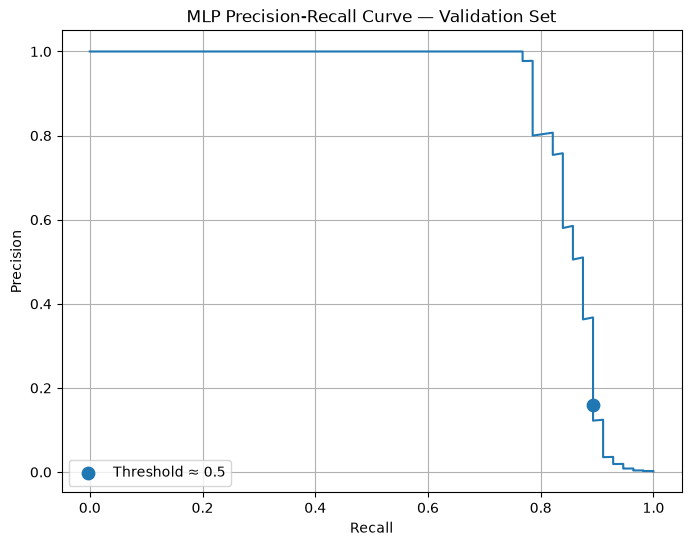

In [141]:
# Import the function required to calculate Precision-Recall values.
from sklearn.metrics import precision_recall_curve

# Calculate Precision and Recall across different probability thresholds.
precision_values, recall_values, threshold_values = precision_recall_curve(
    val_targets_numpy,
    val_probabilities,
)

# Create a Precision-Recall curve plot.
plt.figure(figsize=(8, 6))

# Plot Recall against Precision across the available thresholds.
plt.plot(
    recall_values,
    precision_values,
)

# Mark the Precision and Recall obtained with the current 0.5 threshold.
threshold_index = np.argmin(
    np.abs(threshold_values - THRESHOLD)
)

plt.scatter(
    recall_values[threshold_index],
    precision_values[threshold_index],
    s=80,
    label=f"Threshold ≈ {THRESHOLD}",
)

# Add plot labels and title.
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("MLP Precision-Recall Curve — Validation Set")

# Display the legend and grid.
plt.legend()
plt.grid(True)

# Display the plot.
plt.show()

### 2.14 Threshold Analysis

The effect of different probability thresholds on Precision, Recall, and F1-score is examined using the validation predictions.

This analysis is descriptive and does not yet define an operational threshold.

In [142]:
# Define a set of probability thresholds for diagnostic analysis.
thresholds_to_test = [
    0.10,
    0.50,
    0.70,
    0.80,
    0.90,
    0.95,
    0.99,
    0.999,
]

# Initialize a list to store the metric results for each threshold.
threshold_results = []

# Evaluate the model at each selected threshold.
for threshold in thresholds_to_test:

    # Convert probabilities into binary predictions at the current threshold.
    predictions = (
        val_probabilities >= threshold
    ).astype(int)

    # Calculate Precision at the current threshold.
    precision = precision_score(
        val_targets_numpy,
        predictions,
        zero_division=0,
    )

    # Calculate Recall at the current threshold.
    recall = recall_score(
        val_targets_numpy,
        predictions,
        zero_division=0,
    )

    # Calculate F1-score at the current threshold.
    f1 = f1_score(
        val_targets_numpy,
        predictions,
        zero_division=0,
    )

    # Count the number of transactions classified as fraud.
    predicted_fraud_count = predictions.sum()

    # Store the results for the current threshold.
    threshold_results.append(
        {
            "Threshold": threshold,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "Predicted_Fraud_Count": predicted_fraud_count,
        }
    )

# Create a DataFrame containing the threshold diagnostics.
threshold_results_df = pd.DataFrame(threshold_results)

# Display the results rounded to four decimal places.
threshold_results_df.round(4)

,Threshold,Precision,Recall,F1,Predicted_Fraud_Count
0,0.100,0.0113,0.9464,0.0224,4680
1,0.500,0.1597,0.8929,0.2710,313
2,0.700,0.4153,0.8750,0.5632,118
3,0.800,0.5581,0.8571,0.6761,86
4,0.900,0.7460,0.8393,0.7899,63
5,0.950,0.8000,0.7857,0.7928,55
6,0.990,1.0000,0.7143,0.8333,40
7,0.999,1.0000,0.4643,0.6341,26


## 3. Autoencoder for Fraud Detection

The second Tier 2 model is an Autoencoder designed for anomaly detection.

Unlike the supervised MLP, which learns directly from the fraud labels, the Autoencoder learns to reconstruct the input features from a compressed representation.

For fraud detection, the main idea is to learn the typical structure of legitimate transactions and use the reconstruction error as an anomaly score.

The Autoencoder is trained using legitimate training transactions only. Labels select the legitimate training rows only; they are neither model inputs nor part of the reconstruction loss. Validation and test splits retain both classes.

Per-transaction reconstruction error is the anomaly score. Checkpoint selection uses validation reconstruction loss; Average Precision (AP) is evaluated separately as a fraud-ranking diagnostic using validation labels. The chronological split is preserved.

### 3.1 Autoencoder Training Data

The Autoencoder is trained using legitimate training transactions only. Labels select those rows only; they are not model inputs and do not enter the reconstruction loss. Validation and test splits retain both classes for reconstruction-error analysis.

In [143]:
# Select only legitimate transactions from the scaled training set.
X_train_autoencoder = X_train[y_train == 0].copy()

# Keep the complete scaled validation set for anomaly detection evaluation.
X_val_autoencoder = X_val.copy()

# Keep the complete scaled test set reserved for final evaluation.
X_test_autoencoder = X_test.copy()

# Display the resulting dataset shapes.
print(f"Autoencoder training shape: {X_train_autoencoder.shape}")
print(f"Validation evaluation shape: {X_val_autoencoder.shape}")
print(f"Test evaluation shape: {X_test_autoencoder.shape}")

Autoencoder training shape: (198980, 32)
Validation evaluation shape: (42721, 32)
Test evaluation shape: (42722, 32)


### 3.2 Convert Autoencoder Data to PyTorch Tensors

The Autoencoder requires PyTorch tensors as input.

The training tensor contains only legitimate transactions, while the validation and test tensors contain all transactions and will be used later to calculate reconstruction errors.

In [144]:
# Convert the Autoencoder training data to NumPy arrays with float32 precision.
X_train_autoencoder_array = X_train_autoencoder.to_numpy(
    dtype=np.float32,
    copy=True,
)

# Convert the validation evaluation data to NumPy arrays with float32 precision.
X_val_autoencoder_array = X_val_autoencoder.to_numpy(
    dtype=np.float32,
    copy=True,
)

# Convert the test evaluation data to NumPy arrays with float32 precision.
X_test_autoencoder_array = X_test_autoencoder.to_numpy(
    dtype=np.float32,
    copy=True,
)

# Convert the NumPy arrays into PyTorch tensors.
X_train_autoencoder_tensor = torch.from_numpy(
    X_train_autoencoder_array
)

X_val_autoencoder_tensor = torch.from_numpy(
    X_val_autoencoder_array
)

X_test_autoencoder_tensor = torch.from_numpy(
    X_test_autoencoder_array
)

# Display the tensor shapes and data types.
print(f"Training tensor shape: {X_train_autoencoder_tensor.shape}")
print(f"Validation tensor shape: {X_val_autoencoder_tensor.shape}")
print(f"Test tensor shape: {X_test_autoencoder_tensor.shape}")

print(f"\nTraining tensor dtype: {X_train_autoencoder_tensor.dtype}")

Training tensor shape: torch.Size([198980, 32])
Validation tensor shape: torch.Size([42721, 32])
Test tensor shape: torch.Size([42722, 32])

Training tensor dtype: torch.float32


### 3.3 Autoencoder DataLoader

The Autoencoder will be trained using mini-batches of legitimate transactions.

The validation and test tensors will be kept as complete evaluation datasets and will not be shuffled during evaluation.

In [145]:
# Create a TensorDataset containing only legitimate training transactions.
autoencoder_train_dataset = TensorDataset(
    X_train_autoencoder_tensor
)

# Define the Autoencoder batch size.
AUTOENCODER_BATCH_SIZE = 1024

# Create a reproducible random generator for training batches.
autoencoder_train_generator = torch.Generator()
autoencoder_train_generator.manual_seed(RANDOM_SEED)

# Create the Autoencoder training DataLoader.
autoencoder_train_loader = DataLoader(
    autoencoder_train_dataset,
    batch_size=AUTOENCODER_BATCH_SIZE,
    shuffle=True,
    generator=autoencoder_train_generator,
)

# Calculate the expected number of training batches.
expected_autoencoder_batches = int(
    np.ceil(
        len(autoencoder_train_dataset)
        / AUTOENCODER_BATCH_SIZE
    )
)

# Display the DataLoader configuration.
print(f"Autoencoder training samples: {len(autoencoder_train_dataset)}")
print(f"Autoencoder batch size: {AUTOENCODER_BATCH_SIZE}")
print(f"Autoencoder training batches: {len(autoencoder_train_loader)}")
print(f"Expected training batches: {expected_autoencoder_batches}")

Autoencoder training samples: 198980
Autoencoder batch size: 1024
Autoencoder training batches: 195
Expected training batches: 195


### 3.4 Autoencoder Configuration

The Autoencoder will use a symmetric architecture with a compressed latent representation.

The input contains 32 features. The encoder will progressively reduce the representation from 32 features to 16 and then to 8 latent features. The decoder will reconstruct the original 32-dimensional input.

The model will use ReLU activation functions in the hidden layers and a linear output layer because the input features have already been transformed using RobustScaler.

In [146]:
# Define the number of input features used by the Autoencoder.
AUTOENCODER_INPUT_DIM = X_train_autoencoder_tensor.shape[1]

# Define the size of the first hidden representation.
AUTOENCODER_HIDDEN_DIM = 16

# Define the size of the compressed latent representation.
AUTOENCODER_LATENT_DIM = 8

# Display the Autoencoder architecture dimensions.
print(f"Input dimension: {AUTOENCODER_INPUT_DIM}")
print(f"Hidden dimension: {AUTOENCODER_HIDDEN_DIM}")
print(f"Latent dimension: {AUTOENCODER_LATENT_DIM}")

Input dimension: 32
Hidden dimension: 16
Latent dimension: 8


### 3.5 Autoencoder Model Definition

The Autoencoder consists of an encoder and a decoder.

The encoder compresses the 32 input features into an 8-dimensional latent representation.

The decoder expands the latent representation back to the original 32-dimensional feature space.

ReLU activation functions are used between the linear layers, while the final decoder layer uses a linear output.

In [147]:
# Define the Autoencoder neural network architecture.
class FraudAutoencoder(nn.Module):

    # Initialize the Autoencoder layers.
    def __init__(
        self,
        input_dim,
        hidden_dim,
        latent_dim,
    ):
        # Initialize the parent PyTorch module.
        super().__init__()

        # Define the encoder that compresses the input features.
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
        )

        # Define the decoder that reconstructs the original features.
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    # Define the forward pass through the Autoencoder.
    def forward(self, x):

        # Generate the compressed latent representation.
        latent = self.encoder(x)

        # Reconstruct the original input from the latent representation.
        reconstruction = self.decoder(latent)

        # Return both the reconstruction and latent representation.
        return reconstruction, latent

### 3.6 Create the Autoencoder

The Autoencoder is instantiated using the input, hidden, and latent dimensions defined above.

The model will be moved to the same computation device used by the MLP.

In [148]:
# Create the Autoencoder using the configured architecture dimensions.
autoencoder = FraudAutoencoder(
    input_dim=AUTOENCODER_INPUT_DIM,
    hidden_dim=AUTOENCODER_HIDDEN_DIM,
    latent_dim=AUTOENCODER_LATENT_DIM,
)

# Move the Autoencoder to the selected computation device.
autoencoder = autoencoder.to(device)

# Display the Autoencoder architecture.
print(autoencoder)

FraudAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
  )
)


### 3.7 Autoencoder Parameter Count

The number of trainable parameters will be calculated to verify the size of the Autoencoder before training.

In [149]:
# Calculate the total number of trainable parameters in the Autoencoder.
autoencoder_trainable_parameters = sum(
    parameter.numel()
    for parameter in autoencoder.parameters()
    if parameter.requires_grad
)

# Display the total number of trainable parameters.
print(
    f"Trainable parameters: {autoencoder_trainable_parameters:,}"
)

Trainable parameters: 1,352


### 3.8 Reconstruction Loss

The Autoencoder will use Mean Squared Error (MSE) as the reconstruction loss.

The input batch itself will be used as the reconstruction target because the model is trained to reproduce the original legitimate transaction features.

No fraud labels will be used during Autoencoder training.

In [150]:
# Define Mean Squared Error as the reconstruction loss.
autoencoder_criterion = nn.MSELoss()

# Display the reconstruction loss function.
print(autoencoder_criterion)

MSELoss()


### 3.9 First Forward Pass

A first forward pass will be performed using one training batch.

The purpose is to verify that the Autoencoder receives the expected input shape and produces a reconstruction with the same 32-dimensional feature space.

In [151]:
# Retrieve the first batch of legitimate transactions.
first_autoencoder_batch = next(
    iter(autoencoder_train_loader)
)

# Extract the input tensor from the batch.
first_batch_features = first_autoencoder_batch[0]

# Move the batch to the selected computation device.
first_batch_features = first_batch_features.to(device)

# Generate the reconstruction and latent representation.
first_reconstruction, first_latent = autoencoder(
    first_batch_features
)

# Display the input, reconstruction, and latent shapes.
print(f"Input shape: {first_batch_features.shape}")
print(f"Latent shape: {first_latent.shape}")
print(f"Reconstruction shape: {first_reconstruction.shape}")

Input shape: torch.Size([1024, 32])
Latent shape: torch.Size([1024, 8])
Reconstruction shape: torch.Size([1024, 32])


### 3.10 Initial Reconstruction Loss

The initial reconstruction loss will be calculated before training.

This provides a reference point for the reconstruction error before the Autoencoder has learned the structure of legitimate transactions.

In [152]:
# Calculate the reconstruction loss before Autoencoder training.
initial_reconstruction_loss = autoencoder_criterion(
    first_reconstruction,
    first_batch_features,
)

# Display the initial reconstruction loss.
print(
    f"Initial reconstruction loss: "
    f"{initial_reconstruction_loss.item():.6f}"
)

Initial reconstruction loss: 1.776900


### 3.11 Autoencoder Optimizer

The Autoencoder will be trained using the Adam optimizer.

The learning rate is set to 0.001 to provide a consistent starting point with the MLP training configuration.

In [153]:
# Define the learning rate for Autoencoder training.
AUTOENCODER_LEARNING_RATE = 0.001

# Create the Adam optimizer for the Autoencoder parameters.
autoencoder_optimizer = torch.optim.Adam(
    autoencoder.parameters(),
    lr=AUTOENCODER_LEARNING_RATE,
)

# Display the configured learning rate.
print(
    f"Autoencoder learning rate: "
    f"{AUTOENCODER_LEARNING_RATE}"
)

Autoencoder learning rate: 0.001


### 3.12 Autoencoder Training Configuration

The Autoencoder will be trained for a maximum of 50 epochs.

Early stopping will be based on validation reconstruction loss. Training will stop when the validation reconstruction loss does not improve for 7 consecutive epochs.

The model state with the lowest validation reconstruction loss will be retained.

In [156]:
# Define the maximum number of Autoencoder training epochs.
AUTOENCODER_MAX_EPOCHS = 50

# Define the number of consecutive epochs allowed without validation loss improvement.
AUTOENCODER_EARLY_STOPPING_PATIENCE = 7

# Display the Autoencoder training configuration.
print(
    f"Maximum epochs: {AUTOENCODER_MAX_EPOCHS}"
)
print(
    f"Early stopping patience: "
    f"{AUTOENCODER_EARLY_STOPPING_PATIENCE}"
)

Maximum epochs: 50
Early stopping patience: 7


### 3.13 Full Autoencoder Training

The Autoencoder will now be trained using legitimate training transactions only.

The validation reconstruction loss will be monitored after each epoch.

The model parameters from the epoch with the lowest validation reconstruction loss will be retained.

In [157]:
# Recreate the Autoencoder with freshly initialized parameters.
autoencoder = FraudAutoencoder(
    input_dim=AUTOENCODER_INPUT_DIM,
    hidden_dim=AUTOENCODER_HIDDEN_DIM,
    latent_dim=AUTOENCODER_LATENT_DIM,
)

# Move the new Autoencoder to the selected computation device.
autoencoder = autoencoder.to(device)

# Recreate the Adam optimizer for the new Autoencoder parameters.
autoencoder_optimizer = torch.optim.Adam(
    autoencoder.parameters(),
    lr=AUTOENCODER_LEARNING_RATE,
)

# Initialize the best validation reconstruction loss.
best_autoencoder_val_loss = np.inf

# Initialize the best epoch tracker.
best_autoencoder_epoch = 0

# Initialize the early-stopping counter.
autoencoder_epochs_without_improvement = 0

# Initialize a list to store the Autoencoder training history.
autoencoder_training_history = []

# Train the Autoencoder for up to the configured maximum number of epochs.
for epoch in range(1, AUTOENCODER_MAX_EPOCHS + 1):

    # Put the Autoencoder into training mode.
    autoencoder.train()

    # Initialize the accumulated training loss.
    running_train_loss = 0.0

    # Iterate through all legitimate training batches.
    for (batch_features,) in autoencoder_train_loader:

        # Move the training batch to the selected computation device.
        batch_features = batch_features.to(device)

        # Clear gradients from the previous optimization step.
        autoencoder_optimizer.zero_grad()

        # Generate the reconstruction.
        batch_reconstruction, _ = autoencoder(batch_features)

        # Calculate the reconstruction loss.
        batch_loss = autoencoder_criterion(
            batch_reconstruction,
            batch_features,
        )

        # Calculate gradients through backpropagation.
        batch_loss.backward()

        # Update the Autoencoder parameters.
        autoencoder_optimizer.step()

        # Accumulate the batch loss weighted by batch size.
        running_train_loss += (
            batch_loss.item()
            * batch_features.size(0)
        )

    # Calculate the mean training reconstruction loss.
    train_loss = (
        running_train_loss
        / len(autoencoder_train_loader.dataset)
    )

    # Put the Autoencoder into evaluation mode.
    autoencoder.eval()

    # Disable gradient calculation during validation.
    with torch.no_grad():

        # Move the complete validation tensor to the selected device.
        validation_features = X_val_autoencoder_tensor.to(device)

        # Generate validation reconstructions.
        validation_reconstruction, _ = autoencoder(
            validation_features
        )

        # Calculate the validation reconstruction loss.
        val_loss = autoencoder_criterion(
            validation_reconstruction,
            validation_features,
        ).item()

    # Store the current epoch results.
    autoencoder_training_history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
        }
    )

    # Check whether validation reconstruction loss improved.
    if val_loss < best_autoencoder_val_loss:

        # Update the best validation reconstruction loss.
        best_autoencoder_val_loss = val_loss

        # Store the best epoch.
        best_autoencoder_epoch = epoch

        # Reset the early-stopping counter.
        autoencoder_epochs_without_improvement = 0

        # Save a CPU copy of the best Autoencoder parameters.
        best_autoencoder_state = {
            key: value.detach().cpu().clone()
            for key, value in autoencoder.state_dict().items()
        }

        # Record that the current epoch improved validation loss.
        improvement_status = "improved"

    else:

        # Increase the counter when validation loss does not improve.
        autoencoder_epochs_without_improvement += 1

        # Record that validation loss did not improve.
        improvement_status = "no improvement"

    # Print the current training and validation losses.
    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f} | "
        f"{improvement_status}"
    )

    # Stop training after the configured patience period.
    if (
        autoencoder_epochs_without_improvement
        >= AUTOENCODER_EARLY_STOPPING_PATIENCE
    ):

        # Report the early-stopping event.
        print(
            f"Early stopping triggered after epoch {epoch}. "
            f"Best epoch: {best_autoencoder_epoch}."
        )

        # Exit the training loop.
        break

# Restore the Autoencoder parameters from the best validation epoch.
autoencoder.load_state_dict(best_autoencoder_state)

# Move the restored model to the selected computation device.
autoencoder = autoencoder.to(device)

# Display the final training reference results.
print(
    f"\nBest validation reconstruction loss: "
    f"{best_autoencoder_val_loss:.6f}"
)
print(
    f"Best epoch: {best_autoencoder_epoch}"
)

Epoch 01 | Train Loss: 1.517855 | Val Loss: 1.547928 | improved
Epoch 02 | Train Loss: 0.983497 | Val Loss: 1.107670 | improved
Epoch 03 | Train Loss: 0.743883 | Val Loss: 0.895074 | improved
Epoch 04 | Train Loss: 0.623004 | Val Loss: 0.769643 | improved
Epoch 05 | Train Loss: 0.552032 | Val Loss: 0.718537 | improved
Epoch 06 | Train Loss: 0.517526 | Val Loss: 0.684886 | improved
Epoch 07 | Train Loss: 0.497012 | Val Loss: 0.655255 | improved
Epoch 08 | Train Loss: 0.480776 | Val Loss: 0.631434 | improved
Epoch 09 | Train Loss: 0.465921 | Val Loss: 0.608670 | improved
Epoch 10 | Train Loss: 0.452044 | Val Loss: 0.588294 | improved
Epoch 11 | Train Loss: 0.442196 | Val Loss: 0.576743 | improved
Epoch 12 | Train Loss: 0.433913 | Val Loss: 0.567623 | improved
Epoch 13 | Train Loss: 0.426957 | Val Loss: 0.557314 | improved
Epoch 14 | Train Loss: 0.420797 | Val Loss: 0.536425 | improved
Epoch 15 | Train Loss: 0.415190 | Val Loss: 0.529760 | improved
Epoch 16 | Train Loss: 0.410724 | Val Lo

### 3.14 Reconstruction Error on the Validation Set

The trained Autoencoder will be used to reconstruct every transaction in the validation set.

A reconstruction error will be calculated separately for each transaction.

The resulting reconstruction error will be used as the anomaly score for fraud detection.

In [158]:
# Put the trained Autoencoder into evaluation mode.
autoencoder.eval()

# Move the complete validation dataset to the selected device.
validation_features = X_val_autoencoder_tensor.to(device)

# Disable gradient calculation during inference.
with torch.no_grad():

    # Generate reconstructions for all validation transactions.
    validation_reconstruction, _ = autoencoder(
        validation_features
    )

    # Calculate the squared reconstruction error for each feature.
    validation_squared_error = (
        validation_features - validation_reconstruction
    ) ** 2

    # Calculate the mean reconstruction error for each transaction.
    validation_reconstruction_error = (
        validation_squared_error.mean(dim=1)
    )

# Move the reconstruction errors to the CPU and convert them to NumPy.
validation_reconstruction_error = (
    validation_reconstruction_error
    .cpu()
    .numpy()
)

# Display the reconstruction error array shape.
print(
    f"Validation reconstruction error shape: "
    f"{validation_reconstruction_error.shape}"
)

# Display basic reconstruction error statistics.
print(
    f"Mean reconstruction error: "
    f"{validation_reconstruction_error.mean():.6f}"
)

print(
    f"Median reconstruction error: "
    f"{np.median(validation_reconstruction_error):.6f}"
)

print(
    f"Maximum reconstruction error: "
    f"{validation_reconstruction_error.max():.6f}"
)

Validation reconstruction error shape: (42721,)
Mean reconstruction error: 0.454700
Median reconstruction error: 0.344324
Maximum reconstruction error: 39.299641


### 3.15 Reconstruction Error by Class

The validation reconstruction errors will be compared between legitimate and fraudulent transactions.

The fraud labels are not used during Autoencoder training. They are used here only for evaluation.

If fraudulent transactions generally produce higher reconstruction errors, the reconstruction error may provide useful anomaly detection capability.

In [159]:
# Create a validation DataFrame containing reconstruction errors and true labels.
validation_reconstruction_results = pd.DataFrame(
    {
        "Class": y_val.to_numpy(),
        "Reconstruction_Error": validation_reconstruction_error,
    }
)

# Calculate reconstruction error statistics for legitimate transactions.
legitimate_error = validation_reconstruction_results.loc[
    validation_reconstruction_results["Class"] == 0,
    "Reconstruction_Error",
]

# Calculate reconstruction error statistics for fraudulent transactions.
fraud_error = validation_reconstruction_results.loc[
    validation_reconstruction_results["Class"] == 1,
    "Reconstruction_Error",
]

# Display reconstruction error statistics by class.
print("Legitimate transactions:")
print(legitimate_error.describe())

print("\nFraudulent transactions:")
print(fraud_error.describe())

Legitimate transactions:
count    42665.000000
mean         0.448015
std          0.540505
min          0.076918
25%          0.227201
50%          0.343950
75%          0.560882
max         39.299641
Name: Reconstruction_Error, dtype: float64

Fraudulent transactions:
count    56.000000
mean      5.547912
std       3.076105
min       0.204261
25%       3.279254
50%       5.832056
75%       7.648623
max      14.141395
Name: Reconstruction_Error, dtype: float64


### 3.16 Autoencoder Average Precision

The reconstruction error will be evaluated as an anomaly score using Average Precision (AP).

Higher reconstruction errors indicate a higher likelihood of anomalous behavior.

The fraud labels are used only for evaluation and are not used during Autoencoder training.

In [160]:
# Extract the validation fraud labels as a NumPy array.
y_val_autoencoder = y_val.to_numpy()

# Calculate Average Precision using reconstruction error as the anomaly score.
autoencoder_val_ap = average_precision_score(
    y_val_autoencoder,
    validation_reconstruction_error,
)

# Display the validation Average Precision.
print(
    f"Autoencoder validation AP: "
    f"{autoencoder_val_ap:.6f}"
)

Autoencoder validation AP: 0.285407


### 3.17 Reconstruction Error Threshold Analysis

The reconstruction error will be evaluated at several candidate thresholds.

For each threshold, transactions with reconstruction errors above the threshold will be classified as fraudulent.

Precision, Recall, F1-score, and the number of predicted fraudulent transactions will be calculated using the validation set.

The validation set will be used only for threshold analysis. Test data is not used for threshold selection; earlier EDA and integrity inspection is disclosed in the notebook introduction.

In [161]:
# Define candidate reconstruction error thresholds for validation analysis.
AUTOENCODER_THRESHOLDS = [
    0.5,
    1.0,
    2.0,
    3.0,
    4.0,
    5.0,
    6.0,
    8.0,
    10.0,
]

# Initialize a list to store threshold evaluation results.
autoencoder_threshold_results = []

# Evaluate each candidate reconstruction error threshold.
for threshold in AUTOENCODER_THRESHOLDS:

    # Classify transactions above the threshold as fraudulent.
    predictions = (
        validation_reconstruction_error >= threshold
    ).astype(int)

    # Calculate precision at the current threshold.
    threshold_precision = precision_score(
        y_val_autoencoder,
        predictions,
        zero_division=0,
    )

    # Calculate recall at the current threshold.
    threshold_recall = recall_score(
        y_val_autoencoder,
        predictions,
        zero_division=0,
    )

    # Calculate F1-score at the current threshold.
    threshold_f1 = f1_score(
        y_val_autoencoder,
        predictions,
        zero_division=0,
    )

    # Count the number of transactions classified as fraudulent.
    predicted_fraud_count = predictions.sum()

    # Store the threshold evaluation results.
    autoencoder_threshold_results.append(
        {
            "Threshold": threshold,
            "Precision": threshold_precision,
            "Recall": threshold_recall,
            "F1": threshold_f1,
            "Predicted_Fraud_Count": predicted_fraud_count,
        }
    )

# Convert the results into a DataFrame for inspection.
autoencoder_threshold_results = pd.DataFrame(
    autoencoder_threshold_results
)

# Display the threshold analysis results.
display(autoencoder_threshold_results)

,Threshold,Precision,Recall,F1,Predicted_Fraud_Count
0,0.5,0.003995,0.946429,0.007956,13268
1,1.0,0.024854,0.910714,0.048387,2052
2,2.0,0.173285,0.857143,0.288288,277
3,3.0,0.266667,0.785714,0.398190,165
4,4.0,0.307018,0.625000,0.411765,114
5,5.0,0.344444,0.553571,0.424658,90
6,6.0,0.417910,0.500000,0.455285,67
7,8.0,0.400000,0.250000,0.307692,35
8,10.0,0.125000,0.035714,0.055556,16


### 3.18 Reconstruction Error Distribution by Class

The validation reconstruction error distributions will be visualized separately for legitimate and fraudulent transactions.

The visualization will help assess the degree of overlap between the two classes and provide a visual interpretation of the reconstruction error statistics.

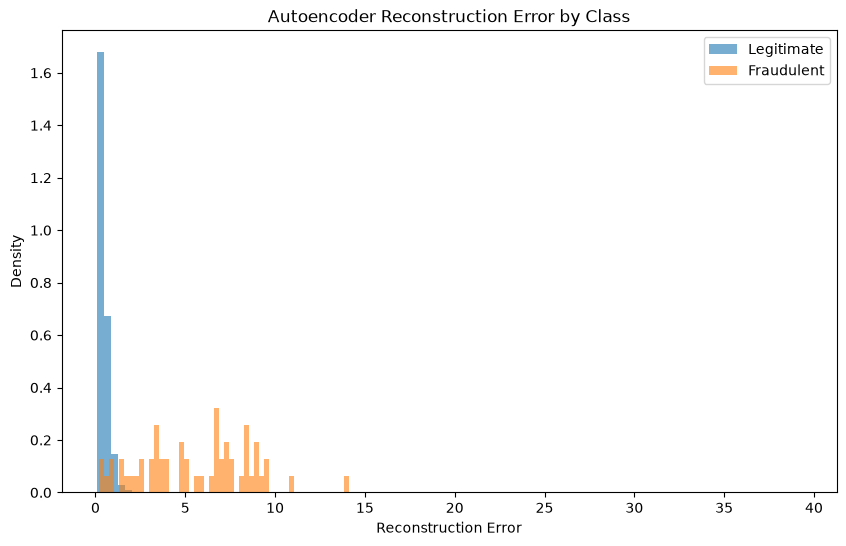

In [162]:
# Create separate reconstruction error arrays for each class.
legitimate_reconstruction_error = validation_reconstruction_results.loc[
    validation_reconstruction_results["Class"] == 0,
    "Reconstruction_Error",
].to_numpy()

fraud_reconstruction_error = validation_reconstruction_results.loc[
    validation_reconstruction_results["Class"] == 1,
    "Reconstruction_Error",
].to_numpy()

# Create a figure for the reconstruction error distributions.
plt.figure(figsize=(10, 6))

# Plot the legitimate transaction reconstruction errors.
plt.hist(
    legitimate_reconstruction_error,
    bins=100,
    alpha=0.6,
    density=True,
    label="Legitimate",
)

# Plot the fraudulent transaction reconstruction errors.
plt.hist(
    fraud_reconstruction_error,
    bins=50,
    alpha=0.6,
    density=True,
    label="Fraudulent",
)

# Add the chart title and axis labels.
plt.title("Autoencoder Reconstruction Error by Class")
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")

# Display the class legend.
plt.legend()

# Display the plot.
plt.show()

### 3.19 Log-Scale Reconstruction Error Distribution

The reconstruction error distributions will be visualized using a logarithmic x-axis.

The logarithmic scale is used because reconstruction errors are strongly right-skewed and contain values across a wide range.

This visualization provides a clearer view of the separation and overlap between legitimate and fraudulent transactions.

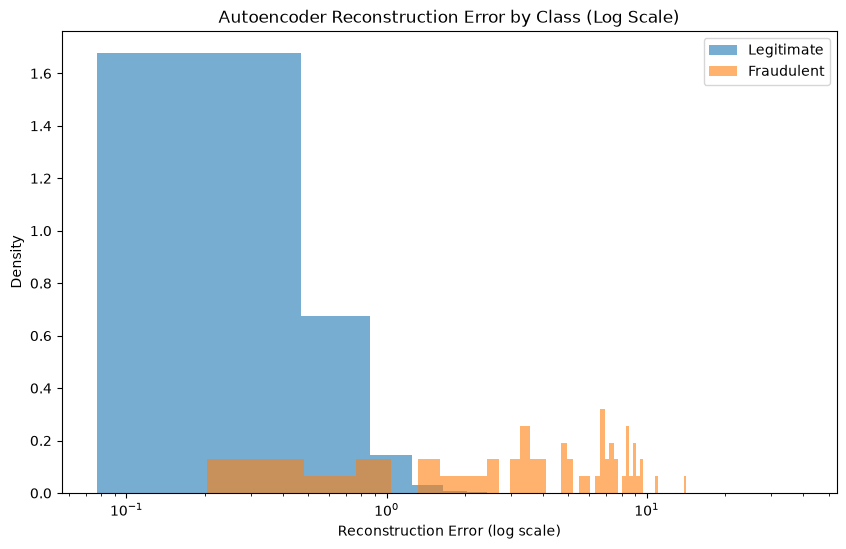

In [163]:
# Create a figure for the log-scale reconstruction error distributions.
plt.figure(figsize=(10, 6))

# Plot legitimate transaction reconstruction errors.
plt.hist(
    legitimate_reconstruction_error,
    bins=100,
    alpha=0.6,
    density=True,
    label="Legitimate",
)

# Plot fraudulent transaction reconstruction errors.
plt.hist(
    fraud_reconstruction_error,
    bins=50,
    alpha=0.6,
    density=True,
    label="Fraudulent",
)

# Use a logarithmic scale for the reconstruction error axis.
plt.xscale("log")

# Add the chart title and axis labels.
plt.title("Autoencoder Reconstruction Error by Class (Log Scale)")
plt.xlabel("Reconstruction Error (log scale)")
plt.ylabel("Density")

# Display the class legend.
plt.legend()

# Display the plot.
plt.show()

### 3.20 Tier 1, MLP and Autoencoder Validation Comparison

The validation performance of the Tier 1 models, MLP, and Autoencoder will be consolidated for comparison.

Average Precision (AP) remains the primary comparison metric.

The Autoencoder uses reconstruction error as its anomaly score, while the supervised models use predicted fraud probabilities.

Test distribution information was inspected for EDA and integrity, but test data was excluded from fitting, tuning, early stopping, threshold optimization, and model selection.

In [164]:
# Define candidate reconstruction error thresholds for the current
# Autoencoder reconstruction errors.
AUTOENCODER_THRESHOLDS = [
    0.5,
    1.0,
    2.0,
    3.0,
    4.0,
    5.0,
    6.0,
    8.0,
    10.0,
]

# Initialize a list to store the updated threshold evaluation results.
autoencoder_threshold_results = []

# Evaluate each candidate reconstruction error threshold.
for threshold in AUTOENCODER_THRESHOLDS:

    # Classify transactions above the threshold as fraudulent.
    predictions = (
        validation_reconstruction_error >= threshold
    ).astype(int)

    # Calculate precision at the current threshold.
    threshold_precision = precision_score(
        y_val_autoencoder,
        predictions,
        zero_division=0,
    )

    # Calculate recall at the current threshold.
    threshold_recall = recall_score(
        y_val_autoencoder,
        predictions,
        zero_division=0,
    )

    # Calculate F1-score at the current threshold.
    threshold_f1 = f1_score(
        y_val_autoencoder,
        predictions,
        zero_division=0,
    )

    # Count the number of transactions classified as fraudulent.
    predicted_fraud_count = predictions.sum()

    # Store the threshold evaluation results.
    autoencoder_threshold_results.append(
        {
            "Threshold": threshold,
            "Precision": threshold_precision,
            "Recall": threshold_recall,
            "F1": threshold_f1,
            "Predicted_Fraud_Count": predicted_fraud_count,
        }
    )

# Convert the results into a DataFrame.
autoencoder_threshold_results = pd.DataFrame(
    autoencoder_threshold_results
)

# Display the updated threshold analysis.
display(autoencoder_threshold_results)

,Threshold,Precision,Recall,F1,Predicted_Fraud_Count
0,0.5,0.003995,0.946429,0.007956,13268
1,1.0,0.024854,0.910714,0.048387,2052
2,2.0,0.173285,0.857143,0.288288,277
3,3.0,0.266667,0.785714,0.398190,165
4,4.0,0.307018,0.625000,0.411765,114
5,5.0,0.344444,0.553571,0.424658,90
6,6.0,0.417910,0.500000,0.455285,67
7,8.0,0.400000,0.250000,0.307692,35
8,10.0,0.125000,0.035714,0.055556,16


In [165]:
# Recalculate Average Precision directly from the current validation labels
# and the current Autoencoder reconstruction errors.
recalculated_autoencoder_val_ap = average_precision_score(
    y_val_autoencoder,
    validation_reconstruction_error,
)

# Display the previously stored and newly recalculated AP values.
print(
    f"Stored Autoencoder validation AP: "
    f"{autoencoder_val_ap:.6f}"
)

print(
    f"Recalculated Autoencoder validation AP: "
    f"{recalculated_autoencoder_val_ap:.6f}"
)

# Check whether the reconstruction error array is unchanged from the
# values currently used for the Autoencoder evaluation.
print(
    f"Reconstruction error observations: "
    f"{len(validation_reconstruction_error)}"
)

Stored Autoencoder validation AP: 0.285407
Recalculated Autoencoder validation AP: 0.285407
Reconstruction error observations: 42721


In [ ]:
# Build this comparison from already computed validation results; no training or new metric calculation occurs here.
autoencoder_comparison_row = pd.DataFrame([{"Model": "Autoencoder", "AP": autoencoder_val_ap}])
validation_model_comparison = pd.concat(
    [comparison_results, autoencoder_comparison_row], ignore_index=True
).sort_values(by="AP", ascending=False).reset_index(drop=True)
display(validation_model_comparison)

In [166]:
# Update the Autoencoder AP in the consolidated validation comparison.
validation_model_comparison.loc[
    validation_model_comparison["Model"] == "Autoencoder",
    "AP",
] = autoencoder_val_ap

# Sort the models by validation Average Precision in descending order.
validation_model_comparison = validation_model_comparison.sort_values(
    by="AP",
    ascending=False,
).reset_index(drop=True)

# Display the updated validation comparison.
display(validation_model_comparison)

,Model,AP
0,Random Forest,0.858000
1,MLP,0.857221
2,XGBoost,0.828400
3,Logistic Regression,0.784900
4,LightGBM,0.681400
5,Autoencoder,0.285407


### 3.21 Autoencoder Results Summary

The Autoencoder was trained exclusively on legitimate transactions from the training set.

The model used a 32-16-8-16-32 architecture with 1,352 trainable parameters and Mean Squared Error as the reconstruction loss.

Training reached the maximum of 50 epochs, with the best validation reconstruction loss of 0.454701 achieved at epoch 50.

The reconstruction error showed a substantial distributional difference between legitimate and fraudulent validation transactions. However, some legitimate transactions also produced high reconstruction errors.

Using reconstruction error as the anomaly score, the Autoencoder achieved a validation Average Precision (AP) of 0.285407.

The best F1-score within the evaluated threshold grid was 0.455285 at a reconstruction error threshold of 6.0, with 41.79% precision and 50.00% recall.

Compared with the supervised models evaluated in this project, the Autoencoder achieved substantially lower Average Precision. This indicates that, for this dataset, reconstruction-based anomaly detection was less effective for fraud ranking than supervised fraud classification.

The Autoencoder results will therefore be retained as an evaluated Tier 2 approach, without selecting it as the leading model.

### 3.22 Save Autoencoder Validation Results

The Autoencoder validation results will be stored in a structured dictionary.

The stored results include the validation Average Precision, the best validation reconstruction loss, the best training epoch, and the best F1-score observed during the evaluated threshold analysis.

These validation results support model comparison. Test distribution inspection during EDA and integrity checks is disclosed in the notebook introduction.

In [167]:
# Identify the threshold with the highest validation F1-score.
best_autoencoder_threshold_row = (
    autoencoder_threshold_results.loc[
        autoencoder_threshold_results["F1"].idxmax()
    ]
)

# Store the verified Autoencoder validation results.
autoencoder_validation_results = {
    "validation_ap": autoencoder_val_ap,
    "best_validation_reconstruction_loss": 0.4547005593776703,
    "best_epoch": 50,
    "best_threshold": best_autoencoder_threshold_row["Threshold"],
    "best_threshold_precision": best_autoencoder_threshold_row["Precision"],
    "best_threshold_recall": best_autoencoder_threshold_row["Recall"],
    "best_threshold_f1": best_autoencoder_threshold_row["F1"],
}

# Display the verified validation results.
for metric_name, metric_value in autoencoder_validation_results.items():
    print(f"{metric_name}: {metric_value}")

validation_ap: 0.28540727476625827
best_validation_reconstruction_loss: 0.4547005593776703
best_epoch: 50
best_threshold: 6.0
best_threshold_precision: 0.417910447761194
best_threshold_recall: 0.5
best_threshold_f1: 0.45528455284552843


## 4. Temporal Deep Learning Models

The next modeling tier evaluates deep learning architectures designed to capture temporal patterns in transaction sequences.

The temporal sequences represent global transaction order rather than customer-, account-, or merchant-level histories. Sequences contain 10 consecutive transactions, with 32 features per transaction and the Class label of the final transaction as target. They are created independently within train, validation, and test, preserving chronological order; the first 9 rows in each split are not targets. The sliding windows overlap, so adjacent sequence observations are correlated.

In [168]:
# Verify that transaction time is monotonically increasing within each split.
print(f"Train Time monotonic: {X_train['Time'].is_monotonic_increasing}")
print(f"Validation Time monotonic: {X_val['Time'].is_monotonic_increasing}")
print(f"Test Time monotonic: {X_test['Time'].is_monotonic_increasing}")

# Display the temporal boundaries of each split.
print(f"Train Time range: {X_train['Time'].min()} -> {X_train['Time'].max()}")
print(f"Validation Time range: {X_val['Time'].min()} -> {X_val['Time'].max()}")
print(f"Test Time range: {X_test['Time'].min()} -> {X_test['Time'].max()}")

# Display the number of observations in each split.
print(f"Train observations: {len(X_train)}")
print(f"Validation observations: {len(X_val)}")
print(f"Test observations: {len(X_test)}")

Train Time monotonic: True
Validation Time monotonic: True
Test Time monotonic: True
Train Time range: -1.4253202529163287 -> 1.3927570105841138
Validation Time range: 1.3927782106116737 -> 1.782837517688773
Test Time range: 1.782837517688773 -> 2.237874909237382
Train observations: 199364
Validation observations: 42721
Test observations: 42722


### 4.1 Temporal Sequence Configuration

Each sequence contains 10 consecutive transactions and 32 features per transaction. The target is the Class label of the final transaction. Sequences are created independently within train, validation, and test, preserving chronological order; the first 9 rows in each split are not targets. Overlapping sliding windows create correlated observations. These sequences represent global transaction order, not entity histories.

In [169]:
# Define the number of consecutive transactions in each temporal sequence.
SEQUENCE_LENGTH = 10

# Calculate the number of possible sequences within each split.
# Each sequence uses the current transaction and the previous 9 transactions.
train_sequence_count = len(X_train) - SEQUENCE_LENGTH + 1
val_sequence_count = len(X_val) - SEQUENCE_LENGTH + 1
test_sequence_count = len(X_test) - SEQUENCE_LENGTH + 1

# Display the sequence configuration and resulting sample counts.
print(f"Sequence length: {SEQUENCE_LENGTH}")
print(f"Train sequences: {train_sequence_count}")
print(f"Validation sequences: {val_sequence_count}")
print(f"Test sequences: {test_sequence_count}")

Sequence length: 10
Train sequences: 199355
Validation sequences: 42712
Test sequences: 42713


In [170]:
def create_sequences(X, y, sequence_length):
    # Convert the feature DataFrame to a NumPy array for efficient slicing.
    X_values = X.to_numpy(dtype=np.float32)

    # Convert the target Series to a NumPy array.
    y_values = y.to_numpy(dtype=np.int64)

    # Create an empty list to store the temporal feature sequences.
    X_sequences = []

    # Create an empty list to store the target of each sequence.
    y_sequences = []

    # Generate sliding-window sequences within the current split.
    for start_idx in range(len(X_values) - sequence_length + 1):
        # Define the end position of the current sequence.
        end_idx = start_idx + sequence_length

        # Store the consecutive transactions in the current window.
        X_sequences.append(X_values[start_idx:end_idx])

        # Use the Class label of the final transaction as the sequence target.
        y_sequences.append(y_values[end_idx - 1])

    # Convert the sequence lists into NumPy arrays.
    X_sequences = np.asarray(X_sequences, dtype=np.float32)
    y_sequences = np.asarray(y_sequences, dtype=np.int64)

    # Return the temporal feature sequences and their corresponding targets.
    return X_sequences, y_sequences

In [171]:
# Create temporal sequences from the training split.
X_train_sequences, y_train_sequences = create_sequences(
    X_train,
    y_train,
    SEQUENCE_LENGTH,
)

# Display the resulting sequence shapes.
print(f"Training sequence shape: {X_train_sequences.shape}")
print(f"Training target shape: {y_train_sequences.shape}")

# Verify that the number of sequences matches the expected calculation.
print(f"Expected training sequences: {train_sequence_count}")
print(f"Actual training sequences: {len(X_train_sequences)}")

Training sequence shape: (199355, 10, 32)
Training target shape: (199355,)
Expected training sequences: 199355
Actual training sequences: 199355


In [172]:
# Create temporal sequences from the validation split.
X_val_sequences, y_val_sequences = create_sequences(
    X_val,
    y_val,
    SEQUENCE_LENGTH,
)

# Create temporal sequences from the test split.
X_test_sequences, y_test_sequences = create_sequences(
    X_test,
    y_test,
    SEQUENCE_LENGTH,
)

# Display the resulting sequence shapes.
print(f"Validation sequence shape: {X_val_sequences.shape}")
print(f"Validation target shape: {y_val_sequences.shape}")

print(f"Test sequence shape: {X_test_sequences.shape}")
print(f"Test target shape: {y_test_sequences.shape}")

# Verify that the number of sequences matches the expected calculations.
print(f"Expected validation sequences: {val_sequence_count}")
print(f"Actual validation sequences: {len(X_val_sequences)}")

print(f"Expected test sequences: {test_sequence_count}")
print(f"Actual test sequences: {len(X_test_sequences)}")

Validation sequence shape: (42712, 10, 32)
Validation target shape: (42712,)
Test sequence shape: (42713, 10, 32)
Test target shape: (42713,)
Expected validation sequences: 42712
Actual validation sequences: 42712
Expected test sequences: 42713
Actual test sequences: 42713


In [173]:
# Calculate the number of legitimate and fraudulent sequence targets in each split.
train_sequence_class_counts = np.bincount(y_train_sequences)
val_sequence_class_counts = np.bincount(y_val_sequences)
test_sequence_class_counts = np.bincount(y_test_sequences)

# Calculate the fraud rate among the sequence targets for each split.
train_sequence_fraud_rate = y_train_sequences.mean()
val_sequence_fraud_rate = y_val_sequences.mean()
test_sequence_fraud_rate = y_test_sequences.mean()

# Display the class counts and fraud rates for each split.
print(
    f"Train sequences - Legitimate: {train_sequence_class_counts[0]}, "
    f"Fraud: {train_sequence_class_counts[1]}, "
    f"Fraud rate: {train_sequence_fraud_rate:.6%}"
)

print(
    f"Validation sequences - Legitimate: {val_sequence_class_counts[0]}, "
    f"Fraud: {val_sequence_class_counts[1]}, "
    f"Fraud rate: {val_sequence_fraud_rate:.6%}"
)

print(
    f"Test sequences - Legitimate: {test_sequence_class_counts[0]}, "
    f"Fraud: {test_sequence_class_counts[1]}, "
    f"Fraud rate: {test_sequence_fraud_rate:.6%}"
)

Train sequences - Legitimate: 198971, Fraud: 384, Fraud rate: 0.192621%
Validation sequences - Legitimate: 42656, Fraud: 56, Fraud rate: 0.131111%
Test sequences - Legitimate: 42661, Fraud: 52, Fraud rate: 0.121743%


In [174]:
# Convert the temporal feature sequences to PyTorch tensors.
X_train_sequences_tensor = torch.tensor(
    X_train_sequences,
    dtype=torch.float32,
)

X_val_sequences_tensor = torch.tensor(
    X_val_sequences,
    dtype=torch.float32,
)

X_test_sequences_tensor = torch.tensor(
    X_test_sequences,
    dtype=torch.float32,
)

# Convert the sequence targets to PyTorch tensors.
y_train_sequences_tensor = torch.tensor(
    y_train_sequences,
    dtype=torch.float32,
)

y_val_sequences_tensor = torch.tensor(
    y_val_sequences,
    dtype=torch.float32,
)

y_test_sequences_tensor = torch.tensor(
    y_test_sequences,
    dtype=torch.float32,
)

# Display the tensor shapes and data types.
print(
    f"Train features: {X_train_sequences_tensor.shape}, "
    f"dtype: {X_train_sequences_tensor.dtype}"
)
print(
    f"Train targets: {y_train_sequences_tensor.shape}, "
    f"dtype: {y_train_sequences_tensor.dtype}"
)

print(
    f"Validation features: {X_val_sequences_tensor.shape}, "
    f"dtype: {X_val_sequences_tensor.dtype}"
)
print(
    f"Validation targets: {y_val_sequences_tensor.shape}, "
    f"dtype: {y_val_sequences_tensor.dtype}"
)

print(
    f"Test features: {X_test_sequences_tensor.shape}, "
    f"dtype: {X_test_sequences_tensor.dtype}"
)
print(
    f"Test targets: {y_test_sequences_tensor.shape}, "
    f"dtype: {y_test_sequences_tensor.dtype}"
)

Train features: torch.Size([199355, 10, 32]), dtype: torch.float32
Train targets: torch.Size([199355]), dtype: torch.float32
Validation features: torch.Size([42712, 10, 32]), dtype: torch.float32
Validation targets: torch.Size([42712]), dtype: torch.float32
Test features: torch.Size([42713, 10, 32]), dtype: torch.float32
Test targets: torch.Size([42713]), dtype: torch.float32


In [175]:
# Define the batch size used by the temporal deep learning models.
TEMPORAL_BATCH_SIZE = 1024

# Create TensorDataset objects for each temporal split.
train_sequence_dataset = TensorDataset(
    X_train_sequences_tensor,
    y_train_sequences_tensor,
)

val_sequence_dataset = TensorDataset(
    X_val_sequences_tensor,
    y_val_sequences_tensor,
)

test_sequence_dataset = TensorDataset(
    X_test_sequences_tensor,
    y_test_sequences_tensor,
)

# Create DataLoaders without shuffling to preserve chronological batch order.
train_sequence_loader = DataLoader(
    train_sequence_dataset,
    batch_size=TEMPORAL_BATCH_SIZE,
    shuffle=False,
)

val_sequence_loader = DataLoader(
    val_sequence_dataset,
    batch_size=TEMPORAL_BATCH_SIZE,
    shuffle=False,
)

test_sequence_loader = DataLoader(
    test_sequence_dataset,
    batch_size=TEMPORAL_BATCH_SIZE,
    shuffle=False,
)

# Display the number of samples and batches for each split.
print(f"Train sequences: {len(train_sequence_dataset)}")
print(f"Train batches: {len(train_sequence_loader)}")

print(f"Validation sequences: {len(val_sequence_dataset)}")
print(f"Validation batches: {len(val_sequence_loader)}")

print(f"Test sequences: {len(test_sequence_dataset)}")
print(f"Test batches: {len(test_sequence_loader)}")

Train sequences: 199355
Train batches: 195
Validation sequences: 42712
Validation batches: 42
Test sequences: 42713
Test batches: 42


In [176]:
# Retrieve the first training batch from the temporal DataLoader.
X_train_batch, y_train_batch = next(iter(train_sequence_loader))

# Display the batch feature and target shapes.
print(f"Training batch features: {X_train_batch.shape}")
print(f"Training batch targets: {y_train_batch.shape}")

# Display the batch data types.
print(f"Training batch feature dtype: {X_train_batch.dtype}")
print(f"Training batch target dtype: {y_train_batch.dtype}")

# Display the number of fraudulent targets in the first batch.
print(f"Fraud targets in first batch: {int(y_train_batch.sum().item())}")

Training batch features: torch.Size([1024, 10, 32])
Training batch targets: torch.Size([1024])
Training batch feature dtype: torch.float32
Training batch target dtype: torch.float32
Fraud targets in first batch: 2


In [179]:
# Define the LSTM classifier for temporal fraud detection.
class LSTMClassifier(nn.Module):
    # Initialise the LSTM architecture.
    def __init__(self, input_size=32, hidden_size=64, num_layers=1):
        # Initialise the parent PyTorch module.
        super().__init__()

        # Define the LSTM layer that processes the transaction sequence.
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
        )

        # Define the final linear layer that produces one fraud logit.
        self.output_layer = nn.Linear(hidden_size, 1)

    # Define the forward pass through the model.
    def forward(self, x):
        # Process the sequence and obtain the hidden states.
        _, (hidden_state, _) = self.lstm(x)

        # Select the final hidden state from the last LSTM layer.
        final_hidden_state = hidden_state[-1]

        # Convert the final hidden representation into one fraud logit.
        output = self.output_layer(final_hidden_state)

        # Remove the final dimension so the output shape matches the targets.
        return output.squeeze(1)


# Create the LSTM model using the temporal configuration defined above.
lstm_model = LSTMClassifier(
    input_size=32,
    hidden_size=64,
    num_layers=1,
).to(device)

# Run one batch through the model without calculating gradients.
with torch.no_grad():
    # Generate fraud logits for the first training batch.
    lstm_batch_output = lstm_model(X_train_batch.to(device))

# Display the model architecture and output shape.
print(lstm_model)
print(f"LSTM batch output shape: {lstm_batch_output.shape}")
print(f"LSTM batch output dtype: {lstm_batch_output.dtype}")

LSTMClassifier(
  (lstm): LSTM(32, 64, batch_first=True)
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)
LSTM batch output shape: torch.Size([1024])
LSTM batch output dtype: torch.float32


In [180]:
# Count legitimate and fraudulent temporal sequences in the training set.
negative_sequence_count = int((y_train_sequences == 0).sum())
positive_sequence_count = int((y_train_sequences == 1).sum())

# Calculate the positive-class weight from the training class distribution.
lstm_pos_weight = negative_sequence_count / positive_sequence_count

# Display the sequence class counts and calculated positive-class weight.
print(f"Legitimate training sequences: {negative_sequence_count}")
print(f"Fraud training sequences: {positive_sequence_count}")
print(f"LSTM pos_weight: {lstm_pos_weight:.6f}")

Legitimate training sequences: 198971
Fraud training sequences: 384
LSTM pos_weight: 518.153646


### 4.2 LSTM Training Configuration

The LSTM will be trained as a supervised binary classifier using the temporal sequences created above.

Because the training sequences remain highly imbalanced, the positive-class weight will be calculated from the training sequence distribution and passed to `BCEWithLogitsLoss`.

The optimizer will use Adam with a learning rate of 0.001.

The validation set monitors model performance during training. Test distribution information was inspected earlier, but test data is excluded from model fitting and selection.

In [181]:
# Convert the calculated positive-class weight to a PyTorch tensor on the training device.
lstm_pos_weight_tensor = torch.tensor(
    [lstm_pos_weight],
    dtype=torch.float32,
    device=device,
)

# Define the weighted binary cross-entropy loss for the LSTM.
lstm_criterion = nn.BCEWithLogitsLoss(
    pos_weight=lstm_pos_weight_tensor,
)

# Define the Adam optimizer for updating the LSTM model parameters.
lstm_optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=0.001,
)

# Display the configured loss and optimizer.
print(f"LSTM positive-class weight: {lstm_pos_weight_tensor.item():.6f}")
print(f"LSTM learning rate: {lstm_optimizer.param_groups[0]['lr']}")

LSTM positive-class weight: 518.153625
LSTM learning rate: 0.001


### 4.3 LSTM Training Configuration

The LSTM will be trained for a maximum of 50 epochs using the Adam optimizer with a learning rate of 0.001.

The weighted binary cross-entropy loss will use the positive-class weight calculated from the training sequence distribution.

Validation Average Precision (AP) will be used as the primary monitoring metric for model selection and early stopping.

The best model will be defined as the model state that achieves the highest validation AP during training.

Test data is excluded from model fitting and selection, although portions of its distribution were inspected for integrity and sequence statistics.


| Parameter               |              Value | Why                                   |
| ----------------------- | -----------------: | ------------------------------------- |
| Maximum epochs          |                 50 | Allow sufficient learning             |
| Learning rate           |              0.001 | Same as MLP                           |
| Batch size              |              1,024 | Already defined                       |
| Loss                    |  BCEWithLogitsLoss | Binary classification                 |
| `pos_weight`            |         518.153646 | Training sequence imbalance           |
| Optimizer               |               Adam | Same as MLP                           |
| Early stopping patience |                  7 | Stop if validation AP stops improving |
| Monitoring metric       |      Validation AP | Primary project metric                |
| Model selection         | Best validation AP | Avoid using final epoch automatically |
| Test set                | Not used for fitting/selection | Final evaluation in notebook 04 |


In [183]:
# Recreate the LSTM model so training starts from freshly initialised weights.
lstm_model = LSTMClassifier(
    input_size=32,
    hidden_size=64,
    num_layers=1,
).to(device)

# Recreate the Adam optimizer for the newly initialised model.
lstm_optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=0.001,
)

# Display the model and optimizer configuration.
print(lstm_model)
print(f"LSTM learning rate: {lstm_optimizer.param_groups[0]['lr']}")

LSTMClassifier(
  (lstm): LSTM(32, 64, batch_first=True)
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)
LSTM learning rate: 0.001


### 4.4 LSTM Validation Evaluation

Validation performance will be evaluated using Average Precision (AP), which is the primary evaluation metric for this highly imbalanced fraud detection problem.

The model will generate fraud logits for all validation sequences. The logits will then be converted into fraud probabilities using the sigmoid function before calculating Average Precision.

The validation set will not be used to update model parameters.

In [184]:
# Define a function to evaluate the LSTM using validation Average Precision.
def evaluate_lstm_ap(model, data_loader):
    # Set the model to evaluation mode.
    model.eval()

    # Create lists to store validation probabilities and targets.
    validation_probabilities = []
    validation_targets = []

    # Disable gradient calculation during validation.
    with torch.no_grad():
        # Process each validation batch.
        for X_batch, y_batch in data_loader:
            # Move the validation batch to the configured device.
            X_batch = X_batch.to(device)

            # Generate fraud logits for the validation batch.
            logits = model(X_batch)

            # Convert logits to fraud probabilities.
            probabilities = torch.sigmoid(logits)

            # Store predictions and targets on the CPU.
            validation_probabilities.extend(
                probabilities.cpu().numpy()
            )
            validation_targets.extend(
                y_batch.numpy()
            )

    # Calculate Average Precision using the complete validation set.
    validation_ap = average_precision_score(
        validation_targets,
        validation_probabilities,
    )

    # Return the validation Average Precision.
    return validation_ap

In [185]:
# Evaluate the freshly initialised LSTM on the validation set.
initial_lstm_validation_ap = evaluate_lstm_ap(
    lstm_model,
    val_sequence_loader,
)

# Display the initial validation Average Precision.
print(f"Initial LSTM validation AP: {initial_lstm_validation_ap:.6f}")

Initial LSTM validation AP: 0.002416


### 4.5 LSTM Training

The LSTM will be trained for a maximum of 50 epochs.

At each epoch, the model will process all training sequences and the mean training loss will be recorded.

After each training epoch, the model will be evaluated on the validation set using Average Precision (AP).

The model state with the highest validation AP will be stored as the best model.

Training will stop early when validation AP does not improve for 7 consecutive epochs.

In [186]:
# Define the maximum number of training epochs.
LSTM_MAX_EPOCHS = 50

# Define the number of epochs allowed without validation AP improvement.
LSTM_EARLY_STOPPING_PATIENCE = 7

# Store the training history for later analysis.
lstm_training_history = []

# Track the best validation AP observed during training.
best_lstm_validation_ap = -np.inf

# Track the epoch that produced the best validation AP.
best_lstm_epoch = 0

# Track the number of consecutive epochs without improvement.
lstm_epochs_without_improvement = 0

# Store the model parameters corresponding to the best validation AP.
best_lstm_state_dict = None

# Start the LSTM training loop.
for epoch in range(1, LSTM_MAX_EPOCHS + 1):

    # Set the model to training mode.
    lstm_model.train()

    # Reset the accumulated training loss for the current epoch.
    total_train_loss = 0.0

    # Process every training batch.
    for X_batch, y_batch in train_sequence_loader:

        # Move the training batch to the configured device.
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Clear gradients from the previous optimization step.
        lstm_optimizer.zero_grad()

        # Generate fraud logits for the current batch.
        logits = lstm_model(X_batch)

        # Calculate the weighted binary cross-entropy loss.
        loss = lstm_criterion(logits, y_batch)

        # Backpropagate the loss through the model.
        loss.backward()

        # Update the model parameters.
        lstm_optimizer.step()

        # Accumulate the batch loss weighted by batch size.
        total_train_loss += loss.item() * X_batch.size(0)

    # Calculate the mean training loss across all training sequences.
    epoch_train_loss = total_train_loss / len(train_sequence_loader.dataset)

    # Evaluate the model on the complete validation set.
    epoch_validation_ap = evaluate_lstm_ap(
        lstm_model,
        val_sequence_loader,
    )

    # Store the metrics from the current epoch.
    lstm_training_history.append(
        {
            "epoch": epoch,
            "train_loss": epoch_train_loss,
            "validation_ap": epoch_validation_ap,
        }
    )

    # Check whether validation AP improved during this epoch.
    if epoch_validation_ap > best_lstm_validation_ap:

        # Update the best validation AP.
        best_lstm_validation_ap = epoch_validation_ap

        # Store the epoch that achieved the best validation AP.
        best_lstm_epoch = epoch

        # Reset the early stopping counter.
        lstm_epochs_without_improvement = 0

        # Store a copy of the best model parameters.
        best_lstm_state_dict = {
            key: value.detach().cpu().clone()
            for key, value in lstm_model.state_dict().items()
        }

        # Mark the current epoch as an improvement.
        improvement_status = "improved"

    else:

        # Increase the number of epochs without improvement.
        lstm_epochs_without_improvement += 1

        # Mark the current epoch as having no improvement.
        improvement_status = "no improvement"

    # Display the metrics and early stopping status for the current epoch.
    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {epoch_train_loss:.6f} | "
        f"Validation AP: {epoch_validation_ap:.6f} | "
        f"{improvement_status}"
    )

    # Stop training when validation AP has not improved for the patience period.
    if lstm_epochs_without_improvement >= LSTM_EARLY_STOPPING_PATIENCE:

        # Display the early stopping information.
        print(
            f"Early stopping triggered after epoch {epoch}. "
            f"Best epoch: {best_lstm_epoch}."
        )

        # Exit the training loop.
        break

Epoch 01 | Train Loss: 0.850305 | Validation AP: 0.815171 | improved
Epoch 02 | Train Loss: 0.383491 | Validation AP: 0.840342 | improved
Epoch 03 | Train Loss: 0.297687 | Validation AP: 0.840254 | no improvement
Epoch 04 | Train Loss: 0.251161 | Validation AP: 0.842295 | improved
Epoch 05 | Train Loss: 0.216249 | Validation AP: 0.845045 | improved
Epoch 06 | Train Loss: 0.185541 | Validation AP: 0.846305 | improved
Epoch 07 | Train Loss: 0.156530 | Validation AP: 0.846911 | improved
Epoch 08 | Train Loss: 0.127861 | Validation AP: 0.848276 | improved
Epoch 09 | Train Loss: 0.098062 | Validation AP: 0.844092 | no improvement
Epoch 10 | Train Loss: 0.078034 | Validation AP: 0.839706 | no improvement
Epoch 11 | Train Loss: 0.080164 | Validation AP: 0.846037 | no improvement
Epoch 12 | Train Loss: 0.073475 | Validation AP: 0.844160 | no improvement
Epoch 13 | Train Loss: 0.051443 | Validation AP: 0.841928 | no improvement
Epoch 14 | Train Loss: 0.037087 | Validation AP: 0.841995 | no impr

### 4.6 Best LSTM Model Restoration

The LSTM model state corresponding to the highest validation Average Precision will be restored before the final validation evaluation.

The best model was identified at epoch 8 with a validation AP of 0.848276.

Restoring this state ensures that subsequent evaluation is performed using the selected model rather than the final model state after early stopping.

In [187]:
# Restore the LSTM parameters from the epoch with the highest validation AP.
lstm_model.load_state_dict(best_lstm_state_dict)

# Evaluate the restored best model on the complete validation set.
restored_lstm_validation_ap = evaluate_lstm_ap(
    lstm_model,
    val_sequence_loader,
)

# Display the stored and recomputed validation AP values.
print(f"Best recorded validation AP: {best_lstm_validation_ap:.6f}")
print(f"Restored model validation AP: {restored_lstm_validation_ap:.6f}")
print(f"Best epoch: {best_lstm_epoch}")

Best recorded validation AP: 0.848276
Restored model validation AP: 0.848276
Best epoch: 8


### 4.7 LSTM Validation Evaluation

The selected LSTM model will be evaluated on the validation set using the project's primary and secondary classification metrics.

Average Precision (AP) will remain the primary metric because of the severe class imbalance.

Precision, Recall, F1-score, and ROC-AUC will be reported as secondary metrics using a classification threshold of 0.5.

The confusion matrix will also be calculated to show the number of legitimate and fraudulent sequences correctly and incorrectly classified.

In [188]:
# Import the classification metrics required for LSTM evaluation.
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

# Set the LSTM to evaluation mode.
lstm_model.eval()

# Create lists to store validation predictions and targets.
lstm_validation_probabilities = []
lstm_validation_targets = []

# Disable gradient calculation during evaluation.
with torch.no_grad():
    # Process the complete validation set batch by batch.
    for X_batch, y_batch in val_sequence_loader:

        # Move the validation features to the configured device.
        X_batch = X_batch.to(device)

        # Generate fraud logits for the current validation batch.
        logits = lstm_model(X_batch)

        # Convert logits to fraud probabilities.
        probabilities = torch.sigmoid(logits)

        # Store probabilities and targets on the CPU.
        lstm_validation_probabilities.extend(
            probabilities.cpu().numpy()
        )
        lstm_validation_targets.extend(
            y_batch.numpy()
        )

# Convert the collected predictions and targets to NumPy arrays.
lstm_validation_probabilities = np.asarray(
    lstm_validation_probabilities
)
lstm_validation_targets = np.asarray(
    lstm_validation_targets
)

# Apply the project's standard classification threshold of 0.5.
lstm_validation_predictions = (
    lstm_validation_probabilities >= 0.5
).astype(int)

# Calculate the primary Average Precision metric.
lstm_validation_ap = average_precision_score(
    lstm_validation_targets,
    lstm_validation_probabilities,
)

# Calculate the secondary classification metrics.
lstm_validation_precision = precision_score(
    lstm_validation_targets,
    lstm_validation_predictions,
    zero_division=0,
)

lstm_validation_recall = recall_score(
    lstm_validation_targets,
    lstm_validation_predictions,
    zero_division=0,
)

lstm_validation_f1 = f1_score(
    lstm_validation_targets,
    lstm_validation_predictions,
    zero_division=0,
)

lstm_validation_roc_auc = roc_auc_score(
    lstm_validation_targets,
    lstm_validation_probabilities,
)

# Calculate the confusion matrix at the 0.5 threshold.
lstm_validation_confusion_matrix = confusion_matrix(
    lstm_validation_targets,
    lstm_validation_predictions,
)

# Display the complete validation results.
print(f"LSTM Validation AP: {lstm_validation_ap:.6f}")
print(f"LSTM Validation Precision@0.5: {lstm_validation_precision:.6f}")
print(f"LSTM Validation Recall@0.5: {lstm_validation_recall:.6f}")
print(f"LSTM Validation F1@0.5: {lstm_validation_f1:.6f}")
print(f"LSTM Validation ROC-AUC: {lstm_validation_roc_auc:.6f}")

# Display the confusion matrix.
print("LSTM Validation Confusion Matrix:")
print(lstm_validation_confusion_matrix)

LSTM Validation AP: 0.848276
LSTM Validation Precision@0.5: 0.100806
LSTM Validation Recall@0.5: 0.892857
LSTM Validation F1@0.5: 0.181159
LSTM Validation ROC-AUC: 0.980846
LSTM Validation Confusion Matrix:
[[42210   446]
 [    6    50]]


### 4.8 LSTM Threshold Analysis

The default classification threshold of 0.5 is used for standardized model comparison, but it may not be appropriate for operational fraud detection.

A range of classification thresholds will therefore be evaluated on the validation set.

Average Precision will remain unchanged because it is calculated from the continuous fraud probabilities rather than from a single classification threshold.

The threshold analysis will be used to understand the Precision-Recall trade-off and identify potential operating points for further evaluation.

In [189]:
# Define the classification thresholds to evaluate on the validation set.
lstm_thresholds = [
    0.10,
    0.50,
    0.70,
    0.80,
    0.90,
    0.95,
    0.99,
    0.999,
]

# Create a list to store the threshold evaluation results.
lstm_threshold_results = []

# Evaluate each classification threshold.
for threshold in lstm_thresholds:

    # Convert fraud probabilities into binary predictions.
    threshold_predictions = (
        lstm_validation_probabilities >= threshold
    ).astype(int)

    # Calculate precision at the current threshold.
    threshold_precision = precision_score(
        lstm_validation_targets,
        threshold_predictions,
        zero_division=0,
    )

    # Calculate recall at the current threshold.
    threshold_recall = recall_score(
        lstm_validation_targets,
        threshold_predictions,
        zero_division=0,
    )

    # Calculate F1-score at the current threshold.
    threshold_f1 = f1_score(
        lstm_validation_targets,
        threshold_predictions,
        zero_division=0,
    )

    # Count the number of transactions classified as fraudulent.
    predicted_fraud_count = int(
        threshold_predictions.sum()
    )

    # Store the results for the current threshold.
    lstm_threshold_results.append(
        {
            "Threshold": threshold,
            "Precision": threshold_precision,
            "Recall": threshold_recall,
            "F1": threshold_f1,
            "Predicted Fraud Count": predicted_fraud_count,
        }
    )

# Convert the results into a DataFrame for easier comparison.
lstm_threshold_results = pd.DataFrame(
    lstm_threshold_results
)

# Display the threshold analysis results.
display(lstm_threshold_results)

,Threshold,Precision,Recall,F1,Predicted Fraud Count
0,0.100,0.018182,0.928571,0.035665,2860
1,0.500,0.100806,0.892857,0.181159,496
2,0.700,0.236967,0.892857,0.374532,211
3,0.800,0.365672,0.875000,0.515789,134
4,0.900,0.618421,0.839286,0.712121,76
5,0.950,0.758065,0.839286,0.796610,62
6,0.990,0.931818,0.732143,0.820000,44
7,0.999,1.000000,0.339286,0.506667,19


### 4.9 LSTM Validation Results Summary

The selected LSTM model achieved its highest validation Average Precision (AP) of 0.848276 at epoch 8.

At the standard classification threshold of 0.5, the model achieved 10.08% precision, 89.29% recall, 18.12% F1-score, and 0.980846 ROC-AUC.

The threshold analysis showed a strong Precision-Recall trade-off. The highest F1-score within the evaluated threshold grid was 0.820000 at a threshold of 0.99, with 93.18% precision and 73.21% recall.

The threshold analysis is considered a validation-stage diagnostic. This threshold analysis is limited to validation data. No production threshold is selected using test results.

## 5. GRU Model

The next experiment evaluates a Gated Recurrent Unit (GRU) model using the same temporal representation established for the LSTM experiment.

The GRU will use the same sequence length, input features, chronological data splits, validation methodology, and primary evaluation metric.

Test data is excluded from model fitting and selection, although its distribution was inspected during EDA and integrity checks.

### 5.1 GRU Introduction and Configuration

The Gated Recurrent Unit (GRU) is a recurrent neural network architecture designed to model sequential patterns while using a simpler gating mechanism than the LSTM.

In this experiment, the GRU will use the same temporal representation as the LSTM:

- Sequence length: 10 transactions
- Input features: 32
- Target: Class label of the final transaction in each sequence

The same chronological train, validation, and test splits will be preserved.

The GRU will be evaluated using the same validation-based methodology as the LSTM, with Average Precision (AP) as the primary model selection metric.

Test data is excluded from model fitting and selection, although its distribution was inspected during EDA and integrity checks.

### 5.2 GRU Architecture

The GRU classifier will use the same input and output configuration as the LSTM model to support a consistent architectural comparison.

The model will use:

- Input size: 32 features per transaction
- Hidden size: 64
- Number of recurrent layers: 1
- Batch-first input representation
- Unidirectional GRU
- One linear output layer producing a single fraud logit

The GRU will not apply a sigmoid activation inside the model. The sigmoid function will be applied only when converting logits into fraud probabilities during evaluation.

Keeping the main architectural dimensions aligned with the LSTM allows the comparison to focus primarily on the difference between the recurrent architectures.

### 5.3 GRU Model Definition

The GRU classifier will process the sequence of transactions and use the final hidden state as the representation of the sequence.

The final hidden representation will be passed to a linear layer that produces one fraud logit.

As with the LSTM model, the model output will remain as a logit during training, and `BCEWithLogitsLoss` will be used to provide numerical stability.

In [190]:
# Define the GRU classifier for temporal fraud detection.
class GRUClassifier(nn.Module):
    # Initialise the GRU architecture.
    def __init__(self, input_size=32, hidden_size=64, num_layers=1):
        # Initialise the parent PyTorch module.
        super().__init__()

        # Define the GRU layer that processes the transaction sequence.
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
        )

        # Define the final linear layer that produces one fraud logit.
        self.output_layer = nn.Linear(hidden_size, 1)

    # Define the forward pass through the model.
    def forward(self, x):
        # Process the sequence and obtain the final hidden state.
        _, hidden_state = self.gru(x)

        # Select the final hidden state from the last GRU layer.
        final_hidden_state = hidden_state[-1]

        # Convert the final hidden representation into one fraud logit.
        output = self.output_layer(final_hidden_state)

        # Remove the final dimension so the output shape matches the targets.
        return output.squeeze(1)

### 5.4 GRU Model Instantiation

The GRU classifier will now be instantiated using the same architectural dimensions defined above.

The model structure will be displayed to verify that the recurrent layer and output layer were created as expected.

In [191]:
# Instantiate the GRU classifier using the defined architecture.
gru_model = GRUClassifier(
    input_size=32,
    hidden_size=64,
    num_layers=1,
)

# Move the GRU model to the configured computation device.
gru_model = gru_model.to(device)

# Display the GRU model architecture.
print(gru_model)

GRUClassifier(
  (gru): GRU(32, 64, batch_first=True)
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)


### 5.5 GRU Forward Pass

Before training the GRU, a forward pass will be performed using the first training batch.

The purpose of this step is to verify that the temporal input shape is compatible with the GRU architecture and that the model produces one output logit for each sequence in the batch.

In [192]:
# Retrieve the first training batch from the temporal DataLoader.
X_gru_batch, y_gru_batch = next(iter(train_sequence_loader))

# Move the input batch to the configured computation device.
X_gru_batch = X_gru_batch.to(device)

# Generate one fraud logit for each sequence in the batch.
gru_batch_output = gru_model(X_gru_batch)

# Display the input and output shapes.
print(f"GRU batch input shape: {X_gru_batch.shape}")
print(f"GRU batch output shape: {gru_batch_output.shape}")

# Display the output data type.
print(f"GRU batch output dtype: {gru_batch_output.dtype}")

GRU batch input shape: torch.Size([1024, 10, 32])
GRU batch output shape: torch.Size([1024])
GRU batch output dtype: torch.float32


### 5.6 GRU Validation Evaluation Function

In [194]:
# Define a function to evaluate the GRU using validation Average Precision.
def evaluate_gru_ap(model, data_loader):
    # Set the model to evaluation mode.
    model.eval()

    # Create lists to store validation probabilities and targets.
    validation_probabilities = []
    validation_targets = []

    # Disable gradient calculation during validation.
    with torch.no_grad():
        # Process each validation batch.
        for X_batch, y_batch in data_loader:
            # Move the validation batch to the configured device.
            X_batch = X_batch.to(device)

            # Generate fraud logits for the validation batch.
            logits = model(X_batch)

            # Convert logits to fraud probabilities.
            probabilities = torch.sigmoid(logits)

            # Store predictions and targets on the CPU.
            validation_probabilities.extend(
                probabilities.cpu().numpy()
            )
            validation_targets.extend(
                y_batch.numpy()
            )

    # Calculate Average Precision using the complete validation set.
    validation_ap = average_precision_score(
        validation_targets,
        validation_probabilities,
    )

    # Return the validation Average Precision.
    return validation_ap

### 5.6 GRU Training Configuration

The GRU will be trained for a maximum of 50 epochs using the Adam optimizer with a learning rate of 0.001.

The weighted binary cross-entropy loss will use the positive-class weight calculated from the training sequence distribution.

Validation Average Precision (AP) will be used as the primary monitoring metric for model selection and early stopping.

The best model will be defined as the model state that achieves the highest validation AP during training.

Early stopping will be applied when validation AP does not improve for 7 consecutive epochs.

Test data is excluded from model fitting and selection, although portions of its distribution were inspected for integrity and sequence statistics.

### 5.7 GRU Loss and Optimizer

The GRU will use weighted binary cross-entropy with logits to account for the severe class imbalance in the training sequences.

The positive-class weight will be calculated from the training sequence distribution only.

The Adam optimizer will be used with a learning rate of 0.001.

In [196]:
# Calculate class counts and positive weight from training sequence labels only.
gru_negative_count = int((y_train_sequences == 0).sum())
gru_positive_count = int((y_train_sequences == 1).sum())
gru_pos_weight = gru_negative_count / gru_positive_count
gru_pos_weight_tensor = torch.tensor(
    gru_pos_weight,
    dtype=torch.float32,
    device=device,
)

# Create the weighted binary cross-entropy loss function.
gru_loss_function = nn.BCEWithLogitsLoss(
    pos_weight=gru_pos_weight_tensor,
)

# Create the Adam optimizer for the GRU parameters.
gru_optimizer = torch.optim.Adam(
    gru_model.parameters(),
    lr=0.001,
)

# Display the training configuration.
print(f"GRU positive-class weight: {gru_pos_weight:.6f}")
print(f"GRU learning rate: {gru_optimizer.param_groups[0]['lr']}")
print(f"GRU loss function: {gru_loss_function}")

GRU positive-class weight: 518.153646
GRU learning rate: 0.001
GRU loss function: BCEWithLogitsLoss()


### 5.8 GRU Training

The GRU will be trained for a maximum of 50 epochs.

At each epoch, the model will process all training sequences and the mean training loss will be recorded.

After each training epoch, the model will be evaluated on the validation set using Average Precision (AP).

The model state with the highest validation AP will be stored as the best model.

Training will stop early when validation AP does not improve for 7 consecutive epochs.

Test data is excluded from fitting and model selection; earlier distribution checks are disclosed in the notebook introduction.

In [197]:
# Define the maximum number of training epochs.
GRU_MAX_EPOCHS = 50

# Define the number of consecutive epochs without improvement allowed.
GRU_PATIENCE = 7

# Initialise variables used to track the best validation performance.
best_gru_validation_ap = -np.inf
best_gru_epoch = 0
epochs_without_improvement = 0
best_gru_state_dict = None

# Create a list to store the training history.
gru_training_history = []

# Start the GRU training loop.
for epoch in range(1, GRU_MAX_EPOCHS + 1):
    # Set the model to training mode.
    gru_model.train()

    # Reset the accumulated training loss.
    running_loss = 0.0
    training_sample_count = 0

    # Process all training batches.
    for X_batch, y_batch in train_sequence_loader:
        # Move the training batch to the configured device.
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Reset gradients from the previous optimization step.
        gru_optimizer.zero_grad()

        # Generate fraud logits for the current batch.
        logits = gru_model(X_batch)

        # Calculate the weighted binary cross-entropy loss.
        loss = gru_loss_function(
            logits,
            y_batch,
        )

        # Calculate gradients through backpropagation.
        loss.backward()

        # Update the GRU parameters.
        gru_optimizer.step()

        # Accumulate the batch loss weighted by the number of samples.
        batch_size = X_batch.size(0)
        running_loss += loss.item() * batch_size
        training_sample_count += batch_size

    # Calculate the mean training loss for the epoch.
    epoch_training_loss = running_loss / training_sample_count

    # Evaluate the current model on the validation set.
    epoch_validation_ap = evaluate_gru_ap(
        gru_model,
        val_sequence_loader,
    )

    # Store the current epoch results.
    gru_training_history.append(
        {
            "Epoch": epoch,
            "Train Loss": epoch_training_loss,
            "Validation AP": epoch_validation_ap,
        }
    )

    # Check whether validation AP has improved.
    if epoch_validation_ap > best_gru_validation_ap:
        # Update the best validation AP.
        best_gru_validation_ap = epoch_validation_ap

        # Store the epoch that achieved the best validation AP.
        best_gru_epoch = epoch

        # Reset the early stopping counter.
        epochs_without_improvement = 0

        # Store a CPU copy of the best model parameters.
        best_gru_state_dict = {
            key: value.detach().cpu().clone()
            for key, value in gru_model.state_dict().items()
        }

        # Display the epoch result and improvement.
        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {epoch_training_loss:.6f} | "
            f"Val AP: {epoch_validation_ap:.6f} | "
            f"Improved"
        )

    else:
        # Increase the number of epochs without validation improvement.
        epochs_without_improvement += 1

        # Display the epoch result without improvement.
        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {epoch_training_loss:.6f} | "
            f"Val AP: {epoch_validation_ap:.6f} | "
            f"No improvement"
        )

    # Stop training when the validation metric has not improved for the patience period.
    if epochs_without_improvement >= GRU_PATIENCE:
        # Display the early stopping information.
        print(
            f"Early stopping after epoch {epoch}. "
            f"Best epoch: {best_gru_epoch}"
        )

        # Exit the training loop.
        break

Epoch 01 | Train Loss: 0.731824 | Val AP: 0.772445 | Improved
Epoch 02 | Train Loss: 0.365300 | Val AP: 0.826211 | Improved
Epoch 03 | Train Loss: 0.289732 | Val AP: 0.838385 | Improved
Epoch 04 | Train Loss: 0.248954 | Val AP: 0.842036 | Improved
Epoch 05 | Train Loss: 0.218338 | Val AP: 0.843658 | Improved
Epoch 06 | Train Loss: 0.188032 | Val AP: 0.840310 | No improvement
Epoch 07 | Train Loss: 0.158255 | Val AP: 0.840275 | No improvement
Epoch 08 | Train Loss: 0.125657 | Val AP: 0.838362 | No improvement
Epoch 09 | Train Loss: 0.094871 | Val AP: 0.834465 | No improvement
Epoch 10 | Train Loss: 0.070316 | Val AP: 0.832179 | No improvement
Epoch 11 | Train Loss: 0.053403 | Val AP: 0.829020 | No improvement
Epoch 12 | Train Loss: 0.041394 | Val AP: 0.828695 | No improvement
Early stopping after epoch 12. Best epoch: 5


### 5.10 Best GRU Model Restoration

The GRU model state corresponding to the highest validation Average Precision will be restored before the final validation evaluation.

The best model was identified at epoch 5 with a validation AP of 0.843658.

Restoring this state ensures that subsequent evaluation is performed using the selected model rather than the final model state after early stopping.

In [198]:
# Restore the GRU parameters from the epoch with the highest validation AP.
gru_model.load_state_dict(best_gru_state_dict)

# Move the restored model to the configured computation device.
gru_model = gru_model.to(device)

# Evaluate the restored GRU on the validation set.
restored_gru_validation_ap = evaluate_gru_ap(
    gru_model,
    val_sequence_loader,
)

# Display the restored validation AP.
print(f"Best GRU epoch: {best_gru_epoch}")
print(f"Stored best validation AP: {best_gru_validation_ap:.6f}")
print(f"Restored validation AP: {restored_gru_validation_ap:.6f}")

Best GRU epoch: 5
Stored best validation AP: 0.843658
Restored validation AP: 0.843658


### 5.11 GRU Validation Evaluation

The selected GRU model will be evaluated on the validation set using the project's primary and secondary classification metrics.

Average Precision (AP) will remain the primary metric because of the severe class imbalance.

Precision, Recall, F1-score, and ROC-AUC will be reported as secondary metrics using a classification threshold of 0.5.

The confusion matrix will also be calculated to show the number of legitimate and fraudulent sequences correctly and incorrectly classified.

In [199]:
# Set the GRU model to evaluation mode.
gru_model.eval()

# Create lists to store validation probabilities and targets.
gru_validation_probabilities = []
gru_validation_targets = []

# Disable gradient calculation during validation.
with torch.no_grad():
    # Process each validation batch.
    for X_batch, y_batch in val_sequence_loader:
        # Move the validation features to the configured device.
        X_batch = X_batch.to(device)

        # Generate fraud logits for the validation batch.
        logits = gru_model(X_batch)

        # Convert logits into fraud probabilities.
        probabilities = torch.sigmoid(logits)

        # Store predictions and targets on the CPU.
        gru_validation_probabilities.extend(
            probabilities.cpu().numpy()
        )
        gru_validation_targets.extend(
            y_batch.numpy()
        )

# Convert the stored predictions and targets to NumPy arrays.
gru_validation_probabilities = np.asarray(
    gru_validation_probabilities
)
gru_validation_targets = np.asarray(
    gru_validation_targets
)

# Calculate Average Precision using the continuous fraud probabilities.
gru_validation_ap = average_precision_score(
    gru_validation_targets,
    gru_validation_probabilities,
)

# Convert probabilities into binary predictions using the standard threshold.
gru_validation_predictions = (
    gru_validation_probabilities >= 0.5
).astype(int)

# Calculate the secondary classification metrics.
gru_validation_precision = precision_score(
    gru_validation_targets,
    gru_validation_predictions,
    zero_division=0,
)

gru_validation_recall = recall_score(
    gru_validation_targets,
    gru_validation_predictions,
    zero_division=0,
)

gru_validation_f1 = f1_score(
    gru_validation_targets,
    gru_validation_predictions,
    zero_division=0,
)

# Calculate ROC-AUC using the continuous fraud probabilities.
gru_validation_roc_auc = roc_auc_score(
    gru_validation_targets,
    gru_validation_probabilities,
)

# Calculate the confusion matrix at the 0.5 threshold.
gru_validation_confusion_matrix = confusion_matrix(
    gru_validation_targets,
    gru_validation_predictions,
)

# Display the GRU validation metrics.
print(f"GRU validation AP: {gru_validation_ap:.6f}")
print(f"GRU validation Precision @ 0.5: {gru_validation_precision:.6f}")
print(f"GRU validation Recall @ 0.5: {gru_validation_recall:.6f}")
print(f"GRU validation F1 @ 0.5: {gru_validation_f1:.6f}")
print(f"GRU validation ROC-AUC: {gru_validation_roc_auc:.6f}")

# Display the confusion matrix.
print("GRU validation confusion matrix:")
print(gru_validation_confusion_matrix)

GRU validation AP: 0.843658
GRU validation Precision @ 0.5: 0.071229
GRU validation Recall @ 0.5: 0.910714
GRU validation F1 @ 0.5: 0.132124
GRU validation ROC-AUC: 0.977572
GRU validation confusion matrix:
[[41991   665]
 [    5    51]]


### 5.13 GRU Threshold Analysis

The standard classification threshold of 0.5 is used for model comparison, but it may not represent an appropriate operating point for fraud detection.

A range of classification thresholds will therefore be evaluated on the validation set.

Average Precision (AP) will remain unchanged because it is calculated from the continuous fraud probabilities rather than from a single classification threshold.

The threshold analysis will be used to examine the Precision-Recall trade-off and identify potential operating points for further evaluation.

No final operating threshold will be selected at this stage.

In [200]:
# Define the classification thresholds to evaluate on the validation set.
gru_thresholds = [0.10, 0.50, 0.70, 0.80, 0.90, 0.95, 0.99, 0.999]

# Create a list to store the threshold evaluation results.
gru_threshold_results = []

# Evaluate each classification threshold.
for threshold in gru_thresholds:
    # Convert fraud probabilities into binary predictions.
    threshold_predictions = (
        gru_validation_probabilities >= threshold
    ).astype(int)

    # Calculate precision at the current threshold.
    threshold_precision = precision_score(
        gru_validation_targets,
        threshold_predictions,
        zero_division=0,
    )

    # Calculate recall at the current threshold.
    threshold_recall = recall_score(
        gru_validation_targets,
        threshold_predictions,
        zero_division=0,
    )

    # Calculate F1-score at the current threshold.
    threshold_f1 = f1_score(
        gru_validation_targets,
        threshold_predictions,
        zero_division=0,
    )

    # Count the number of transactions classified as fraudulent.
    predicted_fraud_count = int(
        threshold_predictions.sum()
    )

    # Store the threshold evaluation results.
    gru_threshold_results.append(
        {
            "Threshold": threshold,
            "Precision": threshold_precision,
            "Recall": threshold_recall,
            "F1": threshold_f1,
            "Predicted Fraud Count": predicted_fraud_count,
        }
    )

# Convert the threshold results into a DataFrame.
gru_threshold_results = pd.DataFrame(
    gru_threshold_results
)

# Display the threshold analysis results.
display(gru_threshold_results)

,Threshold,Precision,Recall,F1,Predicted Fraud Count
0,0.100,0.014785,0.928571,0.029107,3517
1,0.500,0.071229,0.910714,0.132124,716
2,0.700,0.192308,0.892857,0.316456,260
3,0.800,0.316456,0.892857,0.467290,158
4,0.900,0.533333,0.857143,0.657534,90
5,0.950,0.718750,0.821429,0.766667,64
6,0.990,0.951220,0.696429,0.804124,41
7,0.999,1.000000,0.160714,0.276923,9


### 5.14 GRU Validation Results Summary

The selected GRU model achieved its highest validation Average Precision (AP) of 0.843658 at epoch 5.

At the standard classification threshold of 0.5, the model achieved 7.12% precision, 91.07% recall, 13.21% F1-score, and 0.977572 ROC-AUC.

The threshold analysis showed a strong Precision-Recall trade-off. The highest F1-score within the evaluated threshold grid was 0.804124 at a threshold of 0.99, with 95.12% precision and 69.64% recall.

Compared with the LSTM, the GRU achieved slightly lower validation Average Precision and ROC-AUC. At the threshold of 0.99, the GRU also achieved a slightly lower F1-score than the LSTM.

The GRU results will therefore be retained as an evaluated Tier 3 approach, without selecting it as the leading model.

Test data is not used for threshold selection; earlier distribution inspection is disclosed in the notebook introduction.

### 5.15 LSTM vs GRU Comparison

The LSTM and GRU models were evaluated using the same temporal representation, chronological data splits, sequence length, input features, class-weighting strategy, validation metric, and early stopping methodology.

The LSTM achieved a validation Average Precision (AP) of 0.848276, while the GRU achieved 0.843658.

The LSTM therefore achieved slightly better overall fraud ranking performance according to the project's primary metric.

At the standard classification threshold of 0.5, the GRU achieved slightly higher recall, while the LSTM achieved higher precision and F1-score.

At a threshold of 0.99, the LSTM also achieved a slightly higher F1-score than the GRU.

The results suggest that both recurrent architectures are capable of learning useful temporal representations, but the GRU did not provide an improvement over the LSTM for this dataset.

The LSTM will therefore remain the stronger recurrent model within the current Tier 3 experiments.

Test data is not used for threshold selection; earlier EDA and integrity inspection is disclosed in the notebook introduction.

## 6. Consolidated Validation Model Comparison

This section consolidates the validation results obtained across the supervised and deep learning experiments.

The comparison includes the Tier 1 machine learning models, the Tier 2 MLP, and the Tier 3 recurrent neural network models.

The comparison is based exclusively on validation performance. Test distribution information was inspected during EDA and integrity checks, but test data was excluded from model development, selection, and threshold decisions.

Average Precision (AP) is the primary comparison metric because of the severe class imbalance in the fraud detection problem.

Precision, Recall, F1-score, and ROC-AUC at a classification threshold of 0.5 are reported as secondary diagnostics.

The classification threshold of 0.5 is used here only to provide a consistent comparison across models. It is not considered the final operational threshold.

### 6.1 Consolidated Validation Results

The validation results from all evaluated models will be consolidated into a single comparison table.

Average Precision (AP) is the primary metric used to compare model ranking performance.

Precision, Recall, F1-score, and ROC-AUC are reported as secondary metrics using the evaluation threshold associated with each model.

For the Autoencoder, the threshold-dependent metrics correspond to the reconstruction error threshold of 6.0 rather than a probability threshold of 0.5.

In [203]:
# Display the existing model comparison results.
print("comparison_results:")
display(comparison_results)

# Display the existing validation model comparison.
print("validation_model_comparison:")
display(validation_model_comparison)

comparison_results:


,Model,AP,Precision@0.5,Recall@0.5,F1@0.5,ROC-AUC
0,Logistic Regression,0.784900,0.750000,0.535700,0.625000,0.980000
1,Random Forest,0.858000,1.000000,0.678600,0.808500,0.960900
2,XGBoost,0.828400,0.976200,0.732100,0.836700,0.978000
3,LightGBM,0.681400,0.944400,0.607100,0.739100,0.876700
4,MLP,0.857221,0.159744,0.892857,0.271003,0.980068


validation_model_comparison:


,Model,AP
0,Random Forest,0.858000
1,MLP,0.857221
2,XGBoost,0.828400
3,Logistic Regression,0.784900
4,LightGBM,0.681400
5,Autoencoder,0.285407


### 6.2 Add Tier 3 Models to the Comparison

The existing comparison table contains the validation results for the Tier 1 models and the MLP.

The validation results from the LSTM and GRU will now be added using the metrics generated directly by their respective experiments.

This approach avoids manually re-entering previously calculated results and preserves the traceability of the model evaluation pipeline.

The Autoencoder will remain reported separately because its anomaly-detection evaluation does not produce the same set of classification metrics as the supervised models.

In [205]:
# Create a DataFrame containing the verified LSTM validation results.
lstm_comparison_row = pd.DataFrame(
    [
        {
            "Model": "LSTM",
            "AP": lstm_validation_ap,
            "Precision@0.5": lstm_validation_precision,
            "Recall@0.5": lstm_validation_recall,
            "F1@0.5": lstm_validation_f1,
            "ROC-AUC": lstm_validation_roc_auc,
        }
    ]
)

# Create a DataFrame containing the verified GRU validation results.
gru_comparison_row = pd.DataFrame(
    [
        {
            "Model": "GRU",
            "AP": gru_validation_ap,
            "Precision@0.5": gru_validation_precision,
            "Recall@0.5": gru_validation_recall,
            "F1@0.5": gru_validation_f1,
            "ROC-AUC": gru_validation_roc_auc,
        }
    ]
)

# Combine the existing comparison results with the Tier 3 models.
full_supervised_comparison = pd.concat(
    [
        comparison_results,
        lstm_comparison_row,
        gru_comparison_row,
    ],
    ignore_index=True,
)

# Sort all supervised models by the primary metric, Average Precision.
full_supervised_comparison = full_supervised_comparison.sort_values(
    by="AP",
    ascending=False,
).reset_index(drop=True)

# Display the consolidated supervised model comparison.
display(full_supervised_comparison)

,Model,AP,Precision@0.5,Recall@0.5,F1@0.5,ROC-AUC
0,Random Forest,0.858000,1.000000,0.678600,0.808500,0.960900
1,MLP,0.857221,0.159744,0.892857,0.271003,0.980068
2,LSTM,0.848276,0.100806,0.892857,0.181159,0.980846
3,GRU,0.843658,0.071229,0.910714,0.132124,0.977572
4,XGBoost,0.828400,0.976200,0.732100,0.836700,0.978000
5,Logistic Regression,0.784900,0.750000,0.535700,0.625000,0.980000
6,LightGBM,0.681400,0.944400,0.607100,0.739100,0.876700


In [207]:
# Create a compact comparison of Average Precision across all evaluated models.
ap_comparison = pd.DataFrame(
    {
        "Model": [
            "Random Forest",
            "MLP",
            "LSTM",
            "GRU",
            "XGBoost",
            "Logistic Regression",
            "LightGBM",
            "Autoencoder",
        ],
        "AP": [
            comparison_results.loc[
                comparison_results["Model"] == "Random Forest", "AP"
            ].iloc[0],
            comparison_results.loc[
                comparison_results["Model"] == "MLP", "AP"
            ].iloc[0],
            lstm_validation_ap,
            gru_validation_ap,
            comparison_results.loc[
                comparison_results["Model"] == "XGBoost", "AP"
            ].iloc[0],
            comparison_results.loc[
                comparison_results["Model"] == "Logistic Regression", "AP"
            ].iloc[0],
            comparison_results.loc[
                comparison_results["Model"] == "LightGBM", "AP"
            ].iloc[0],
            autoencoder_val_ap,
        ],
    }
)

# Sort all models by the primary metric, Average Precision.
ap_comparison = ap_comparison.sort_values(
    by="AP",
    ascending=False,
).reset_index(drop=True)

# Display the Average Precision comparison.
display(ap_comparison)

,Model,AP
0,Random Forest,0.858000
1,MLP,0.857221
2,LSTM,0.848276
3,GRU,0.843658
4,XGBoost,0.828400
5,Logistic Regression,0.784900
6,LightGBM,0.681400
7,Autoencoder,0.285407


### 6.3 Consolidated Model Comparison

The validation results show that the Random Forest achieved the highest Average Precision (AP) among all evaluated models, with an AP of 0.858000.

The MLP achieved a very similar AP of 0.857221, indicating that the supervised tabular deep learning approach was competitive with the best traditional machine learning model.

The recurrent temporal models achieved slightly lower AP values. The LSTM reached 0.848276, while the GRU reached 0.843658. Therefore, the temporal deep learning approaches did not improve fraud ranking performance over the Random Forest or MLP for this dataset.

Among the remaining supervised models, XGBoost achieved an AP of 0.828400, followed by Logistic Regression at 0.784900 and LightGBM at 0.681400.

The Autoencoder achieved an AP of 0.285407, substantially below the supervised approaches. This indicates that reconstruction-based anomaly detection was less effective than supervised classification for ranking fraudulent transactions in this dataset.

Overall, the results demonstrate that increasing model complexity did not automatically produce better fraud detection performance. The Random Forest and MLP provided the strongest validation Average Precision, while the recurrent models provided useful temporal modeling experiments without outperforming the leading tabular approaches.

The threshold-dependent metrics will be considered separately from Average Precision because the classification threshold has a direct impact on Precision, Recall, and F1-score.

Random Forest remains the final selected model because it led on validation AP. No production operating threshold is selected using test results.

Test distribution and integrity were inspected before final evaluation, but test data was excluded from fitting, selection, and threshold optimization. Notebook 04 performs the first final model evaluation; interpret its results as a held-out evaluation rather than a strictly blind holdout.